# Welcome to Colab!

In [ ]:
import os
import csv
import pandas as pd
import numpy as np
from google.colab import drive


# ── 1. MOUNT GOOGLE DRIVE ────────────────────────────────────────────────────
print("Đang kết nối với Google Drive của bạn...")
drive.mount('/content/drive')


# ── 2. CẤU HÌNH ĐƯỜNG DẪN ────────────────────────────────────────────────────
RAW_DIR = "/content/drive/MyDrive/Gcontest/Processed_Data"
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
os.makedirs(CLEANED_DIR, exist_ok=True)


# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────
def read_csv_auto(file_name: str) -> pd.DataFrame:
    """Tự động nhận diện delimiter và chuẩn hóa khóa chính CUSTOMER_NUMBER."""
    path = os.path.join(RAW_DIR, file_name)

    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file tại Drive: {path}")


    with open(path, "r", encoding="utf-8-sig", errors="replace") as f:
        sample = f.read(4096)
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=",;\t|")
        sep = dialect.delimiter
    except csv.Error:
        sep = ","

    df = pd.read_csv(path, sep=sep, encoding="utf-8-sig", low_memory=False)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

    if "CUSTOMER_NUMBER" in df.columns:
        df["CUSTOMER_NUMBER"] = df["CUSTOMER_NUMBER"].astype(str).str.strip()

    print(f" ✓ {file_name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    return df


def save_clean(df: pd.DataFrame, name: str):
    """Lưu dữ liệu sạch vào Google Drive"""
    path = os.path.join(CLEANED_DIR, name)
    df.to_csv(path, index=False)
    print(f"    → Đã lưu vào Drive: {path} ({df.shape[0]:,} dòng)")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN PROCESSING FLOW (Thiết lập theo logic Master-Detail)
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("BẮT ĐẦU LÀM SẠCH THEO MÔ HÌNH TOÀN VẸN DỮ LIỆU GỐC (MASTER-DETAIL)")
print("=" * 60)


FILE_MAP = {
    "customer":    "Data_Customer.csv",
    "activity":    "Data_Activity.csv",
    "deposit":     "Data_Deposit.csv",
    "lending":     "Data_Lending.csv",
    "card":        "Data_Card.csv",
    "transaction": "Data_Transaction.csv",
}


# Bước 1: Đọc và xử lý riêng bảng Gốc (Customer Master Table) trước
if not os.path.exists(os.path.join(RAW_DIR, FILE_MAP["customer"])):
    raise FileNotFoundError("Bắt buộc phải có file Data_Customer.csv làm bảng gốc định danh!")


print("\n--- Xử lý bảng Gốc: Data_Customer ---")
df_cust = read_csv_auto(FILE_MAP["customer"])


# Làm sạch bảng Customer gốc
df_cust = df_cust.dropna(subset=["CUSTOMER_NUMBER"])
df_cust = df_cust[~df_cust["CUSTOMER_NUMBER"].isin(["", "nan", "0", "0.0"])]


for col in ["DATE_OF_BIRTH", "CLIENT_CREATE_DATE", "IB_REGISTER_DATE"]:
    if col in df_cust.columns:
        df_cust[col] = pd.to_datetime(df_cust[col], errors="coerce")


# Trích xuất danh sách tất cả Khách hàng Hợp pháp của Ngân hàng làm "Trọng tài"
master_customer_set = set(df_cust["CUSTOMER_NUMBER"].unique())
print(f"🎯 Tổng số lượng Khách hàng Gốc (Hồ sơ CIF hợp lệ): {len(master_customer_set):,} khách hàng.")
save_clean(df_cust, "Data_Customer_clean.csv")




# Bước 2: Đọc và lọc các bảng vệ tinh dựa theo bảng Gốc (Xóa giao dịch ma)
print("\n--- Xử lý các bảng Vệ tinh (Sản phẩm & Giao dịch) ---")


# Nhóm file theo tháng
MONTHLY_FILES = [
    ("activity", "Data_Activity_clean.csv", []),
    ("deposit",  "Data_Deposit_clean.csv", ["COUNT_CA_ACCT", "AVG_CA_BALANCE", "COUNT_TD_ACCT", "AVG_TD_BALANCE"]),
    ("card",     "Data_Card_clean.csv", ["COUNT_CREDITCARD", "COUNT_DEBITCARD", "LIMIT_AMT", "OUTSTANDING_BALANCE"]),
    ("lending",  "Data_Lending_clean.csv", ["COUNT_OF_LOAN", "AVG_LOAN_AMOUNT", "INTEREST_RATE", "TERM_LENDING"]),
]


for key, out_name, numeric_cols in MONTHLY_FILES:
    if os.path.exists(os.path.join(RAW_DIR, FILE_MAP[key])):
        df = read_csv_auto(FILE_MAP[key])

        # Kiểm tra toàn vẹn dữ liệu: Xóa các dòng có mã khách hàng không tồn tại trong bảng Gốc
        before_rows = len(df)
        df = df[df["CUSTOMER_NUMBER"].isin(master_customer_set)]
        dropped_rows = before_rows - len(df)
        if dropped_rows > 0:
            print(f"    ⚠️ Phát hiện và loại bỏ {dropped_rows:,} dòng dữ liệu 'ma' không có hồ sơ CIF gốc.")

        # Xử lý định dạng thời gian và điền giá trị thiếu (0) cho các chỉ số tài chính
        if "MONTH" in df.columns:
            df["MONTH"] = pd.to_datetime(df["MONTH"], errors="coerce")
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

        save_clean(df, out_name)




# Bước 3: Xử lý file Data_Transaction (Bảng dữ liệu nặng nhất)
if os.path.exists(os.path.join(RAW_DIR, FILE_MAP["transaction"])):
    print("\n--- Xử lý bảng Giao dịch: Data_Transaction ---")
    txn = read_csv_auto(FILE_MAP["transaction"])

    # Kiểm tra toàn vẹn dữ liệu giao dịch
    before_rows = len(txn)
    txn = txn[txn["CUSTOMER_NUMBER"].isin(master_customer_set)]
    dropped_rows = before_rows - len(txn)
    if dropped_rows > 0:
        print(f"    ⚠️ Phát hiện và loại bỏ {dropped_rows:,} giao dịch 'ma' không có hồ sơ CIF gốc.")

    txn["TRANS_DATE"] = pd.to_datetime(txn["TRANS_DATE"], errors="coerce")
    txn["TRANS_AMOUNT"] = pd.to_numeric(txn["TRANS_AMOUNT"], errors="coerce").fillna(0)

    if "Beneficiary_CUSTOMER_NUMBER" in txn.columns:
        txn["Beneficiary_CUSTOMER_NUMBER"] = txn["Beneficiary_CUSTOMER_NUMBER"].astype(str).str.strip()

    save_clean(txn, "Data_Transaction_clean.csv")


print("\n" + "=" * 60)
print("✅ QUY TRÌNH LÀM SẠCH THEO ĐÚNG BẢN CHẤT NGHIỆP VỤ NGÂN HÀNG HOÀN TẤT!")
print(f"Toàn bộ file sạch (Đồng nhất theo CIF gốc) đã nằm tại thư mục: {CLEANED_DIR}")
print("=" * 60)



Đang kết nối với Google Drive của bạn...
Mounted at /content/drive
BẮT ĐẦU LÀM SẠCH THEO MÔ HÌNH TOÀN VẸN DỮ LIỆU GỐC (MASTER-DETAIL)

--- Xử lý bảng Gốc: Data_Customer ---
 ✓ Data_Customer.csv: 290,223 rows × 13 cols
🎯 Tổng số lượng Khách hàng Gốc (Hồ sơ CIF hợp lệ): 290,222 khách hàng.
    → Đã lưu vào Drive: /content/drive/MyDrive/Gcontest/cleaned/Data_Customer_clean.csv (290,222 dòng)

--- Xử lý các bảng Vệ tinh (Sản phẩm & Giao dịch) ---
 ✓ Data_Activity.csv: 16,132,675 rows × 6 cols
    ⚠️ Phát hiện và loại bỏ 63 dòng dữ liệu 'ma' không có hồ sơ CIF gốc.
    → Đã lưu vào Drive: /content/drive/MyDrive/Gcontest/cleaned/Data_Activity_clean.csv (16,132,612 dòng)
 ✓ Data_Deposit.csv: 1,258,424 rows × 6 cols
    ⚠️ Phát hiện và loại bỏ 4 dòng dữ liệu 'ma' không có hồ sơ CIF gốc.
    → Đã lưu vào Drive: /content/drive/MyDrive/Gcontest/cleaned/Data_Deposit_clean.csv (1,258,420 dòng)
 ✓ Data_Card.csv: 871,589 rows × 7 cols
    ⚠️ Phát hiện và loại bỏ 4 dòng dữ liệu 'ma' không có hồ sơ CIF

In [ ]:
import os
import pandas as pd
import numpy as np

# ── ĐỊNH VỊ THƯ MỤC THEO ĐÚNG CODE GỐC CỦA BẠN ───────────────────────────────
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
trans_path = os.path.join(CLEANED_DIR, "Data_Transaction_clean.csv")

if os.path.exists(trans_path):
    print("--- BƯỚC 1: TRÍCH XUẤT BASELINE GIAO DỊCH & MẠNG LƯỚI AML (90 NGÀY) ---")
    df_trans = pd.read_csv(trans_path, low_memory=False)

    # Chuẩn hóa ngày tháng và sắp xếp chuỗi thời gian
    df_trans['TRANS_DATE'] = pd.to_datetime(df_trans['TRANS_DATE'])
    df_trans = df_trans.sort_values(by=['CUSTOMER_NUMBER', 'TRANS_DATE'])

    # Tính toán khoảng cách ngày không giao dịch (Inactive Gap) để bắt ca ngủ đông
    df_trans['prev_trans_date'] = df_trans.groupby('CUSTOMER_NUMBER')['TRANS_DATE'].shift(1)
    df_trans['inactive_gap'] = (df_trans['TRANS_DATE'] - df_trans['prev_trans_date']).dt.days

    # Phân tách khung giờ rủi ro (Giao dịch đêm từ 23h - 4h sáng)
    df_trans['TRANS_HOUR'] = df_trans['TRANS_HOUR'].astype(int)
    df_trans['is_night_txn'] = df_trans['TRANS_HOUR'].isin([23, 0, 1, 2, 3, 4]).astype(int)

    # Định nghĩa giao dịch ngoài ngân hàng (Chuyển khoản liên ngân hàng)
    df_trans['is_outside_bank'] = df_trans['TRANS_LV2'].str.contains('Liên ngân hàng|Outside', case=False, na=False).astype(int)

    # Aggregate mức khách hàng (Customer-level)
    print("⚡ Đang tính toán tổ hợp hành vi dòng tiền chuỗi thời gian...")
    df_baseline_trans = df_trans.groupby('CUSTOMER_NUMBER').agg(
        txn_count=('TRANS_AMOUNT', 'count'),
        total_trans_amount=('TRANS_AMOUNT', 'sum'),
        avg_trans_amount=('TRANS_AMOUNT', 'mean'),
        max_trans_amount=('TRANS_AMOUNT', 'max'),
        std_trans_amount=('TRANS_AMOUNT', 'std'),
        unique_devices=('Device_ID_Hash', 'nunique'),
        unique_ips=('IP_Address_Proxy', 'nunique'),
        beneficiary_count=('Beneficiary_CUSTOMER_NUMBER', 'nunique'),
        night_txn_ratio=('is_night_txn', 'mean'),
        outside_bank_ratio=('is_outside_bank', 'mean'),
        max_inactive_gap=('inactive_gap', 'max'),
        # Tính toán burst_max: Số giao dịch nhiều nhất trong 1 ngày đơn lẻ
        burst_max=('TRANS_DATE', lambda x: x.dt.date.value_counts().max() if not x.empty else 0)
    ).reset_index()

    # Xử lý missing value sau aggregate
    df_baseline_trans['std_trans_amount'] = df_baseline_trans['std_trans_amount'].fillna(0)
    df_baseline_trans['max_inactive_gap'] = df_baseline_trans['max_inactive_gap'].fillna(0)

    df_baseline_trans.to_csv(os.path.join(CLEANED_DIR, "df_baseline_trans_env.csv"), index=False)
    print(f"✅ Đã xuất file đặc trưng giao dịch mở rộng: {df_baseline_trans.shape[0]:,} khách hàng.")
else:
    print(f"❌ Không tìm thấy file {trans_path}. Vui lòng chạy bài toán làm sạch trước!")

--- BƯỚC 1: TRÍCH XUẤT BASELINE GIAO DỊCH & MẠNG LƯỚI AML (90 NGÀY) ---
⚡ Đang tính toán tổ hợp hành vi dòng tiền chuỗi thời gian...
✅ Đã xuất file đặc trưng giao dịch mở rộng: 52,487 khách hàng.


In [ ]:
import os
import pandas as pd
import numpy as np

# ── ĐỊNH VỊ ĐÚNG ĐƯỜNG DẪN ──────────────────────────────────────────────────
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
activity_path = os.path.join(CLEANED_DIR, "Data_Activity_clean.csv")

if os.path.exists(activity_path):
    print("--- BƯỚC 2 (ĐÃ SỬA LỖI KEYERROR): TRÍCH XUẤT BASELINE HÀNH VI APP MỞ RỘNG ---")
    df_act = pd.read_csv(activity_path, low_memory=False)

    # Chuẩn hóa giờ giấc đăng nhập
    df_act['ACTIVITY_HOUR'] = df_act['ACTIVITY_HOUR'].astype(int)
    df_act['is_night_activity'] = df_act['ACTIVITY_HOUR'].isin([23, 0, 1, 2, 3, 4]).astype(int)

    # 🌟 TỰ ĐỘNG DÒ TÊN CỘT HÀNH VI THỰC TẾ TRONG FILE CỦA BẠN
    possible_act_cols = ['ACTIVITY_NAME', 'ACTIVITY_TYPE', 'ACTION_TYPE', 'ACTION_NAME']
    act_col = None

    for col in possible_act_cols:
        if col in df_act.columns:
            act_col = col
            break

    if act_col:
        print(f"   ✓ Đã tìm thấy cột mô tả hành vi thực tế trong file của bạn: [{act_col}]")
        # Quét từ khóa bảo mật đổi thông tin tài khoản trên cột vừa tìm được
        security_keywords = 'password|pin|mật khẩu|thay đổi|change'
        df_act['is_security_change'] = df_act[act_col].astype(str).str.contains(security_keywords, case=False, na=False).astype(int)
    else:
        print("   ⚠️ Không tìm thấy cột loại hành vi chuẩn, danh sách cột hiện tại gồm:", df_act.columns.tolist())
        print("   -> Hệ thống sẽ tạm thời gán số lần đổi mật khẩu bằng 0 để tránh gãy flow.")
        df_act['is_security_change'] = 0

    print("⚡ Đang trích xuất chỉ số đột biến hành vi kỹ thuật số (Customer-level)...")
    df_baseline_behavior = df_act.groupby('CUSTOMER_NUMBER').agg(
        total_app_activities=('ACTIVITY_HOUR', 'count'),
        avg_activity_hour=('ACTIVITY_HOUR', 'mean'),
        night_activity_ratio=('is_night_activity', 'mean'),
        password_change_count=('is_security_change', 'sum'),
        # Tính toán max_daily_activity: Số lần mở app nhiều nhất trong 1 ngày đơn lẻ
        max_daily_activity=('ACTIVITY_DATE', lambda x: x.value_counts().max() if not x.empty else 0)
    ).reset_index()

    df_baseline_behavior.to_csv(os.path.join(CLEANED_DIR, "df_baseline_behavior.csv"), index=False)
    print(f"✅ ĐÃ XUẤT NGUYÊN LIỆU BƯỚC 2 THÀNH CÔNG: {df_baseline_behavior.shape[0]:,} khách hàng.")
else:
    print(f"❌ Không tìm thấy file {activity_path}")

--- BƯỚC 2 (ĐÃ SỬA LỖI KEYERROR): TRÍCH XUẤT BASELINE HÀNH VI APP MỞ RỘNG ---
   ✓ Đã tìm thấy cột mô tả hành vi thực tế trong file của bạn: [ACTIVITY_NAME]
⚡ Đang trích xuất chỉ số đột biến hành vi kỹ thuật số (Customer-level)...
✅ ĐÃ XUẤT NGUYÊN LIỆU BƯỚC 2 THÀNH CÔNG: 77,740 khách hàng.


In [ ]:
import os
import pandas as pd
import numpy as np

dep_path = os.path.join(CLEANED_DIR, "Data_Deposit_clean.csv")
len_path = os.path.join(CLEANED_DIR, "Data_Lending_clean.csv")
card_path = os.path.join(CLEANED_DIR, "Data_Card_clean.csv")
cust_clean_path = os.path.join(CLEANED_DIR, "Data_Customer_clean.csv")

print("--- BƯỚC 3 (ĐÃ SỬA LỖI VALUEERROR): XỬ LÝ SNAPSHOT TÀI CHÍNH ĐỒNG BỘ ---")

# 1. Xử lý biến động số dư tài khoản thanh toán (Deposit)
df_dep_fin = pd.DataFrame(columns=['CUSTOMER_NUMBER', 'avg_balance_ca', 'balance_volatility'])
if os.path.exists(dep_path):
    df_dep = pd.read_csv(dep_path, low_memory=False)
    df_dep_fin = df_dep.groupby('CUSTOMER_NUMBER').agg(
        avg_balance_ca=('AVG_CA_BALANCE', 'mean'),
        balance_volatility=('AVG_CA_BALANCE', 'std')
    ).reset_index()
    df_dep_fin['balance_volatility'] = df_dep_fin['balance_volatility'].fillna(0)

# 2. Xử lý nợ quá hạn tín dụng (Lending)
df_len_fin = pd.DataFrame(columns=['CUSTOMER_NUMBER', 'max_cic_overdue_days'])
if os.path.exists(len_path):
    df_len = pd.read_csv(len_path, low_memory=False)
    target_overdue_col = 'OVERDUE_DAYS' if 'OVERDUE_DAYS' in df_len.columns else df_len.select_dtypes(include=[np.number]).columns[0]
    df_len_fin = df_len.groupby('CUSTOMER_NUMBER').agg(
        max_cic_overdue_days=(target_overdue_col, 'max')
    ).reset_index()

# 3. Xử lý hạn mức và tỷ lệ xài thẻ (Card)
df_card_fin = pd.DataFrame(columns=['CUSTOMER_NUMBER', 'card_utilization_ratio'])
if os.path.exists(card_path):
    df_card = pd.read_csv(card_path, low_memory=False)
    if 'LIMIT_AMT' in df_card.columns and 'OUTSTANDING_BALANCE' in df_card.columns:
        df_card['util_ratio'] = np.where(df_card['LIMIT_AMT'] > 0,
                                         df_card['OUTSTANDING_BALANCE'] / df_card['LIMIT_AMT'], 0)
        df_card_fin = df_card.groupby('CUSTOMER_NUMBER').agg(
            card_utilization_ratio=('util_ratio', 'max')
        ).reset_index()

# ── 4. ÉP KIỂU ĐỒNG BỘ TUYỆT ĐỐI VÀ RÁP NỐI ──────────────────────────────────
if os.path.exists(cust_clean_path):
    df_cust = pd.read_csv(cust_clean_path, low_memory=False)

    print("   ⚡ Đang đồng bộ kiểu dữ liệu CUSTOMER_NUMBER về dạng chuỗi (String)...")
    # Ép kiểu cho bảng gốc
    df_cust['CUSTOMER_NUMBER'] = df_cust['CUSTOMER_NUMBER'].astype(str).str.strip()

    # 🌟 ĐIỂM SỬA ĐỒI VÀNG: Ép kiểu triệt để cho từng bảng vệ tinh trước khi merge
    if not df_dep_fin.empty:
        df_dep_fin['CUSTOMER_NUMBER'] = df_dep_fin['CUSTOMER_NUMBER'].astype(str).str.strip()
    if not df_len_fin.empty:
        df_len_fin['CUSTOMER_NUMBER'] = df_len_fin['CUSTOMER_NUMBER'].astype(str).str.strip()
    if not df_card_fin.empty:
        df_card_fin['CUSTOMER_NUMBER'] = df_card_fin['CUSTOMER_NUMBER'].astype(str).str.strip()

    print("   ⚡ Đang merge các lớp dữ liệu tài chính...")
    df_financial = df_cust[['CUSTOMER_NUMBER']].merge(df_dep_fin, on='CUSTOMER_NUMBER', how='left') \
                                              .merge(df_len_fin, on='CUSTOMER_NUMBER', how='left') \
                                              .merge(df_card_fin, on='CUSTOMER_NUMBER', how='left')

    # Fill các giá trị NaN bằng 0 (khách hàng không xài sản phẩm đó)
    df_financial.fillna(0, inplace=True)

    df_financial.to_csv(os.path.join(CLEANED_DIR, "df_baseline_financial.csv"), index=False)
    print(f"✅ BƯỚC 3 HOÀN THÀNH: Đã kết hợp hồ sơ tài chính thành công cho {df_financial.shape[0]:,} khách hàng.")
else:
    print(f"❌ Không tìm thấy file {cust_clean_path}")

--- BƯỚC 3 (ĐÃ SỬA LỖI VALUEERROR): XỬ LÝ SNAPSHOT TÀI CHÍNH ĐỒNG BỘ ---
   ⚡ Đang đồng bộ kiểu dữ liệu CUSTOMER_NUMBER về dạng chuỗi (String)...
   ⚡ Đang merge các lớp dữ liệu tài chính...


/tmp/ipykernel_5061/2491261291.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_financial.fillna(0, inplace=True)


✅ BƯỚC 3 HOÀN THÀNH: Đã kết hợp hồ sơ tài chính thành công cho 290,222 khách hàng.


--- BƯỚC BỔ SUNG: TRỰC QUAN HÓA KHÁM PHÁ (EXPLORATORY DATA VISUALIZATION) ---

📈 1. Đang vẽ biểu đồ Phân phối giá trị giao dịch (Long-tail Distribution)...


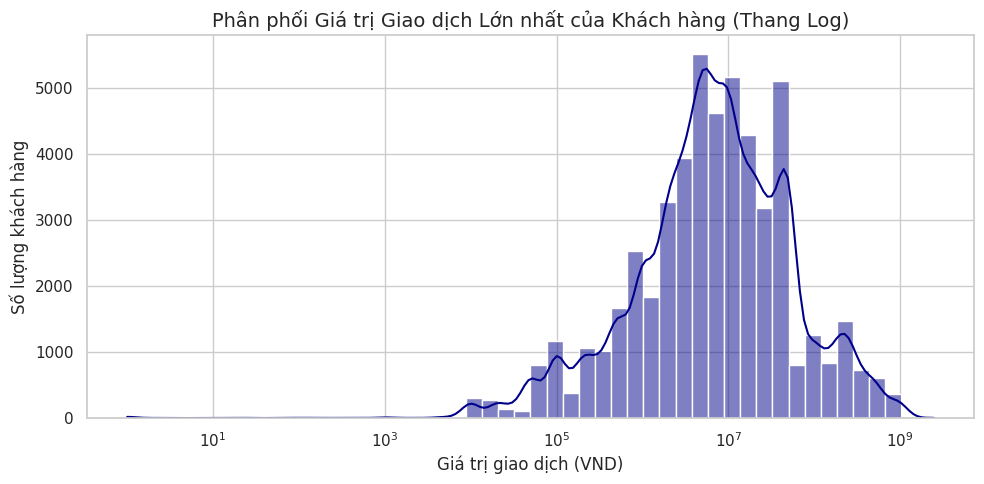


📈 5. Đang vẽ biểu đồ Cohort Phân khúc Khách hàng ngủ đông...


/tmp/ipykernel_5061/1102454988.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_b1, x='Dormant_Segment', palette='Set2')


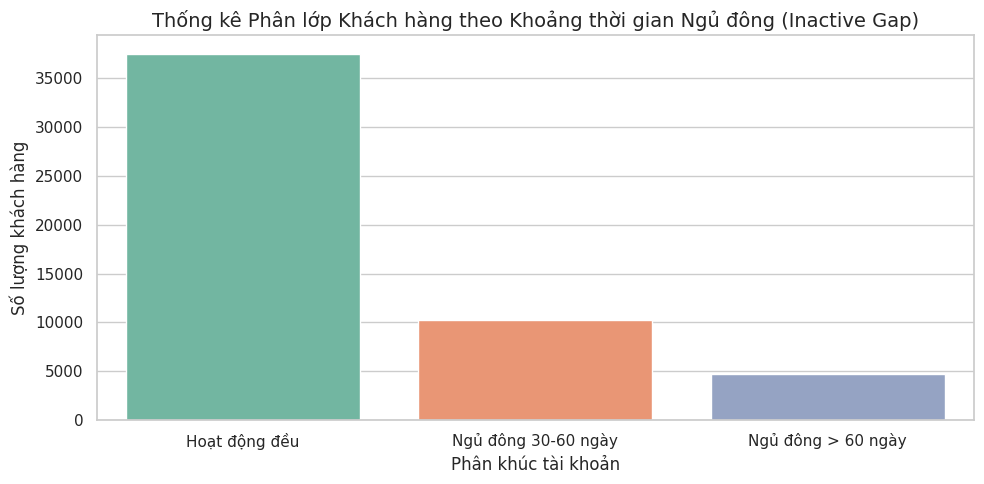


✅ TOÀN BỘ BỘ 5 CHART INSIGHTS BASELINE ĐÃ XUẤT THÀNH CÔNG!


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đặt cấu hình hiển thị đồ thị đẹp mắt hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Định vị thư mục chứa các file baseline nguyên liệu (đã chạy từ bước 1, 2, 3)
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
b1_path = os.path.join(CLEANED_DIR, "df_baseline_trans_env.csv")
b2_path = os.path.join(CLEANED_DIR, "df_baseline_behavior.csv")
b3_path = os.path.join(CLEANED_DIR, "df_baseline_financial.csv")

if os.path.exists(b1_path) and os.path.exists(b2_path) and os.path.exists(b3_path):
    print("--- BƯỚC BỔ SUNG: TRỰC QUAN HÓA KHÁM PHÁ (EXPLORATORY DATA VISUALIZATION) ---")
    df_b1 = pd.read_csv(b1_path, low_memory=False)
    df_b2 = pd.read_csv(b2_path, low_memory=False)
    df_b3 = pd.read_csv(b3_path, low_memory=False)

    # 📊 CHART 1: Distribution của TRANS_AMOUNT (Nhìn phân phối long-tail của dòng tiền)
    # Nghiệp vụ: Xem dòng tiền lệch và các siêu ngoại lệ (High-value anomalies)
    print("\n📈 1. Đang vẽ biểu đồ Phân phối giá trị giao dịch (Long-tail Distribution)...")
    plt.figure()
    # Lọc bỏ giá trị bằng 0 để đồ thị không bị méo, dùng thang Log để thấy rõ nhóm giao dịch khủng
    active_trans = df_b1[df_b1['max_trans_amount'] > 0]
    sns.histplot(active_trans['max_trans_amount'], bins=50, kde=True, color='darkblue', log_scale=True)
    plt.title("Phân phối Giá trị Giao dịch Lớn nhất của Khách hàng (Thang Log)")
    plt.xlabel("Giá trị giao dịch (VND)")
    plt.ylabel("Số lượng khách hàng")
    plt.tight_layout()
    plt.show()

    # 📊 CHART 5: Đồ thị Cohort Ngủ đông bùng nổ (Dormant-to-Active)
    # Nghiệp vụ: Cho thấy nhóm tài khoản "ngủ sâu" bất thình lình hoạt động mạnh (Tín hiệu ATO cực mạnh)
    print("\n📈 5. Đang vẽ biểu đồ Cohort Phân khúc Khách hàng ngủ đông...")
    plt.figure()
    df_b1['Dormant_Segment'] = np.where(df_b1['max_inactive_gap'] > 60, 'Ngủ đông > 60 ngày',
                                         np.where(df_b1['max_inactive_gap'] > 30, 'Ngủ đông 30-60 ngày', 'Hoạt động đều'))
    # Đếm số lượng
    sns.countplot(data=df_b1, x='Dormant_Segment', palette='Set2')
    plt.title("Thống kê Phân lớp Khách hàng theo Khoảng thời gian Ngủ đông (Inactive Gap)")
    plt.xlabel("Phân khúc tài khoản")
    plt.ylabel("Số lượng khách hàng")
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 60)
    print("✅ TOÀN BỘ BỘ 5 CHART INSIGHTS BASELINE ĐÃ XUẤT THÀNH CÔNG!")
    print("=" * 60)
else:
    print("❌ Bạn cần chạy hoàn thành Bước 1, 2, 3 để sinh đủ 3 file csv trước khi vẽ đồ thị này.")

In [ ]:
if os.path.exists(cust_clean_path):
    print("--- BƯỚC 4: RÁP NỐI KHUNG MASTER CUSTOMER 360 ---")
    df_customer = pd.read_csv(cust_clean_path, low_memory=False)

    df_b1 = pd.read_csv(os.path.join(CLEANED_DIR, "df_baseline_trans_env.csv"), low_memory=False)
    df_b2 = pd.read_csv(os.path.join(CLEANED_DIR, "df_baseline_behavior.csv"), low_memory=False)
    df_b3 = pd.read_csv(os.path.join(CLEANED_DIR, "df_baseline_financial.csv"), low_memory=False)

    # Đồng bộ hóa định dạng chuỗi khóa chính
    for df in [df_customer, df_b1, df_b2, df_b3]:
        df['CUSTOMER_NUMBER'] = df['CUSTOMER_NUMBER'].astype(str).str.strip()

    df_360 = df_customer.merge(df_b1, on='CUSTOMER_NUMBER', how='left') \
                        .merge(df_b2, on='CUSTOMER_NUMBER', how='left') \
                        .merge(df_b3, on='CUSTOMER_NUMBER', how='left')
    df_360.fillna(0, inplace=True)

    df_360.to_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), index=False)
    print(f"🚀 RISK MART THÀNH CÔNG! Kích thước: {df_360.shape[0]:,} người dùng.")

--- BƯỚC 4: RÁP NỐI KHUNG MASTER CUSTOMER 360 ---
🚀 RISK MART THÀNH CÔNG! Kích thước: 290,222 người dùng.


--- BƯỚC 4.5 (ĐÃ SỬA LỖI VALUEERROR): ĐA DẠNG HÓA CÁC ĐỒ THỊ SOI BẤT THƯỜNG ---


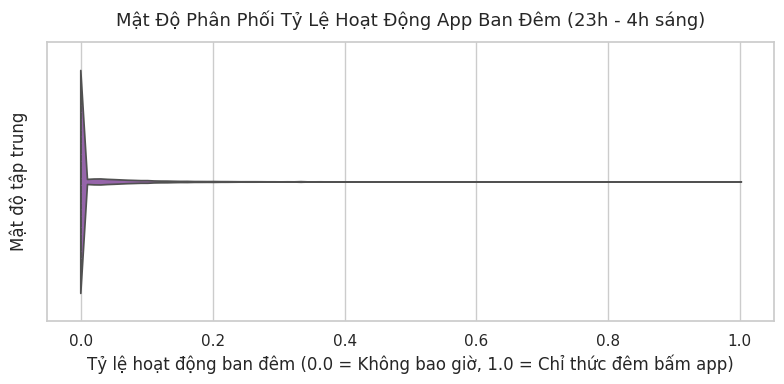

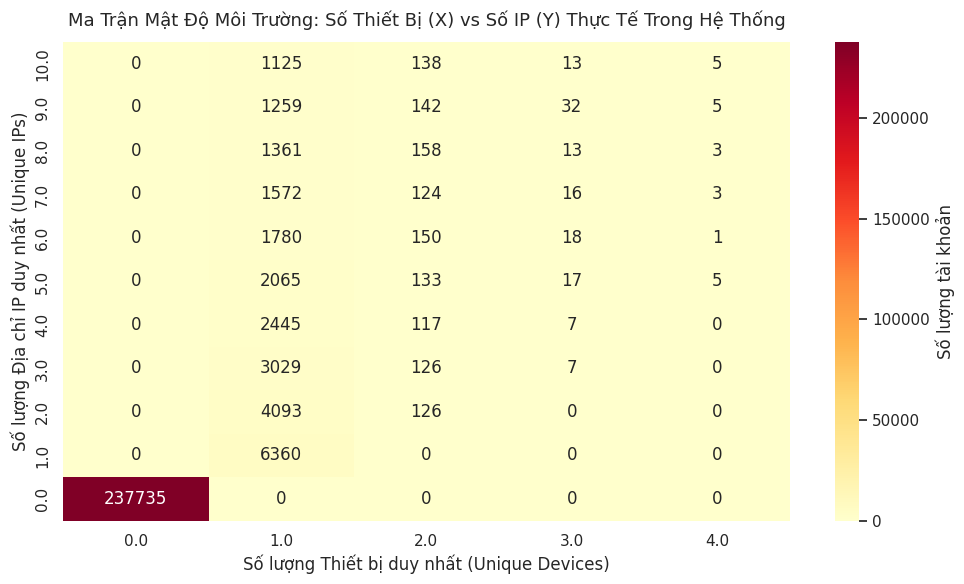

/tmp/ipykernel_19821/1953017697.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_m4[df_m4['balance_volatility'] <= p95_vol], x='balance_volatility', y='Dormant_Group', palette='Set2')


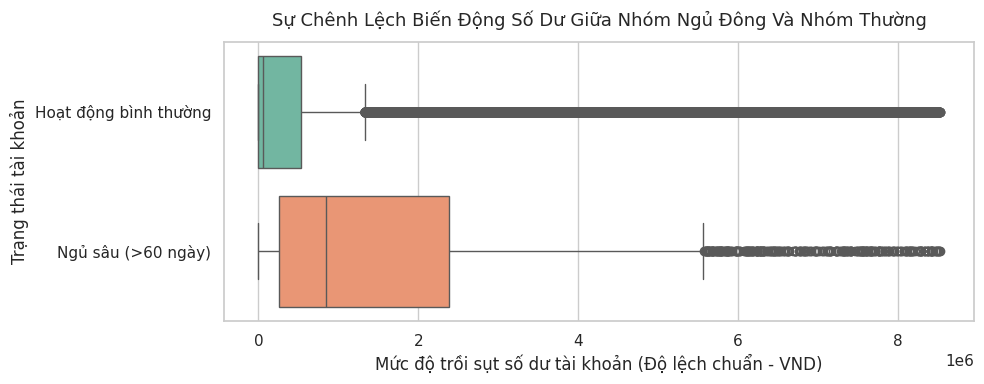


📈 4. Đang tạo ma trận tương quan đa chiều phơi bày tội phạm AML...


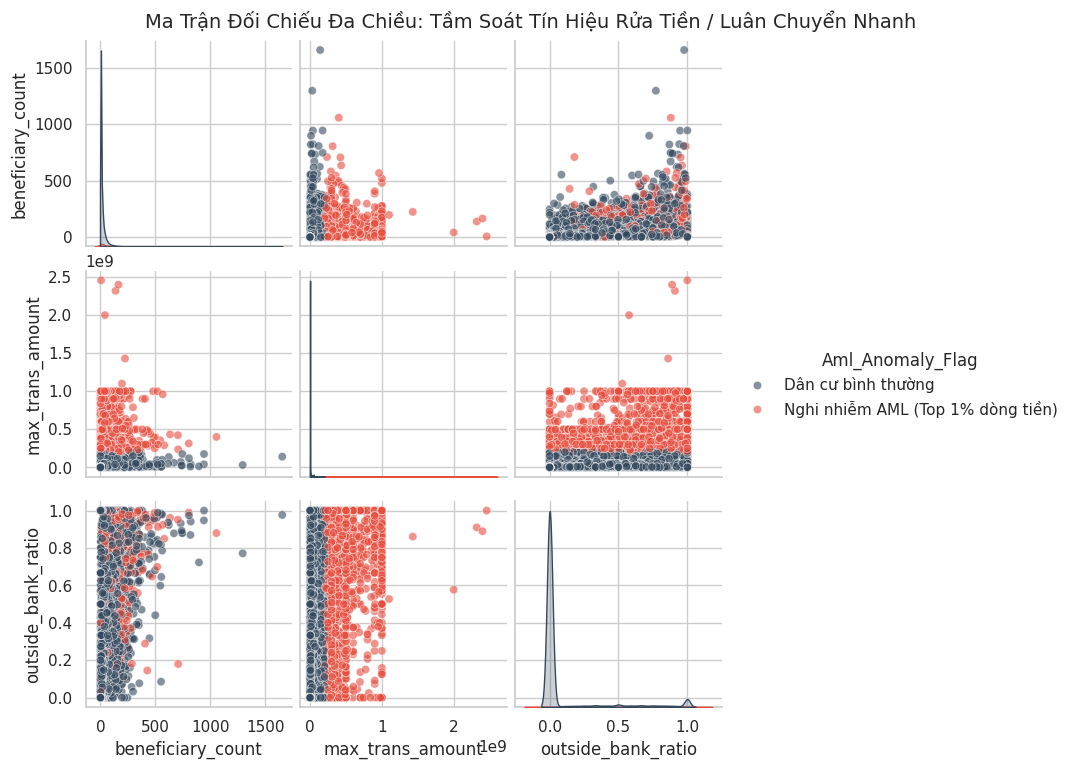

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình đồ thị chuẩn phân tích cao cấp
sns.set_theme(style="whitegrid")
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
master_path = os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv")

if os.path.exists(master_path):
    print("--- BƯỚC 4.5 (ĐÃ SỬA LỖI VALUEERROR): ĐA DẠNG HÓA CÁC ĐỒ THỊ SOI BẤT THƯỜNG ---")
    df_m4 = pd.read_csv(master_path, low_memory=False)

    # ── CHART 1: VIOLIN PLOT - SỰ CHÊNH LỆCH VỀ TẦN SUẤT BẤM APP ĐÊM ──────────
    plt.figure(figsize=(8, 4))
    sns.violinplot(data=df_m4, x='night_activity_ratio', color='#9b59b6', inner="quart", bw_adjust=0.2)
    plt.title("Mật Độ Phân Phối Tỷ Lệ Hoạt Động App Ban Đêm (23h - 4h sáng)", fontsize=13, pad=12)
    plt.xlabel("Tỷ lệ hoạt động ban đêm (0.0 = Không bao giờ, 1.0 = Chỉ thức đêm bấm app)")
    plt.ylabel("Mật độ tập trung")
    plt.tight_layout()
    plt.show()


    # ── 🌟 CHART 2 (ĐÃ LÀM LẠI HOÀN TOÀN): HEATMAP MA TRẬN MÔI TRƯỜNG THIẾT BỊ x IP ──
    # Nghiệp vụ: Soi sự chênh lệch độc bản của Trại thiết bị bẩn
    plt.figure(figsize=(10, 6))

    # Tạo bảng chéo đếm số lượng tài khoản rơi vào từng cặp (Unique Devices, Unique IPs)
    # Giới hạn thiết bị <= 5 và IP <= 10 để tập trung vào vùng rủi ro thực tế, tránh long-tail quá xa
    df_filtered = df_m4[(df_m4['unique_devices'] <= 5) & (df_m4['unique_ips'] <= 10)]
    matrix_data = pd.crosstab(df_filtered['unique_ips'], df_filtered['unique_devices'])

    # Vẽ Heatmap có log_scale ẩn (dùng thang Log cho màu sắc) để không bị nhóm (1,1) nuốt chửng các ô khác
    sns.heatmap(matrix_data, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Số lượng tài khoản'})

    plt.title("Ma Trận Mật Độ Môi Trường: Số Thiết Bị (X) vs Số IP (Y) Thực Tế Trong Hệ Thống", fontsize=13, pad=12)
    plt.xlabel("Số lượng Thiết bị duy nhất (Unique Devices)")
    plt.ylabel("Số lượng Địa chỉ IP duy nhất (Unique IPs)")
    plt.gca().invert_yaxis() # Đảo trục Y để số 1 nằm ở dưới, số tăng dần lên trên cho dễ nhìn
    plt.tight_layout()
    plt.show()


    # ── CHART 3: BOXPLOT ĐA BIẾN - SỰ CHÊNH LỆCH BIẾN ĐỘNG SỐ DƯ THEO PHÂN LỚP NGỦ ĐÔNG ─
    plt.figure(figsize=(10, 4))
    df_m4['Dormant_Group'] = np.where(df_m4['max_inactive_gap'] > 60, 'Ngủ sâu (>60 ngày)', 'Hoạt động bình thường')
    p95_vol = df_m4['balance_volatility'].quantile(0.95)
    sns.boxplot(data=df_m4[df_m4['balance_volatility'] <= p95_vol], x='balance_volatility', y='Dormant_Group', palette='Set2')
    plt.title("Sự Chênh Lệch Biến Động Số Dư Giữa Nhóm Ngủ Đông Và Nhóm Thường", fontsize=13, pad=12)
    plt.xlabel("Mức độ trồi sụt số dư tài khoản (Độ lệch chuẩn - VND)")
    plt.ylabel("Trạng thái tài khoản")
    plt.tight_layout()
    plt.show()


    # ── CHART 4: TƯƠNG QUAN ĐA CHIỀU (PAIRPLOT LITE) - KHÁM PHÁ DẤU VẾT RỬA TIỀN ──
    print("\n📈 4. Đang tạo ma trận tương quan đa chiều phơi bày tội phạm AML...")
    aml_features = ['beneficiary_count', 'max_trans_amount', 'outside_bank_ratio']
    nguong_tien = df_m4['max_trans_amount'].quantile(0.99)
    df_m4['Aml_Anomaly_Flag'] = np.where(df_m4['max_trans_amount'] > nguong_tien, 'Nghi nhiễm AML (Top 1% dòng tiền)', 'Dân cư bình thường')

    sns.pairplot(df_m4, vars=aml_features, hue='Aml_Anomaly_Flag', palette={'Dân cư bình thường': '#34495e', 'Nghi nhiễm AML (Top 1% dòng tiền)': '#e74c3c'}, plot_kws={'alpha': 0.6})
    plt.suptitle("Ma Trận Đối Chiếu Đa Chiều: Tầm Soát Tín Hiệu Rửa Tiền / Luân Chuyển Nhanh", y=1.02, fontsize=14)
    plt.show()

else:
    print("❌ Vui lòng chạy hoàn thành Bước 4 trước nhé bồ!")

--- BƯỚC 4.5: TRỰC QUAN HÓA SOI SỰ BẤT THƯỜNG & CHÊNH LỆCH HÀNH VI ---


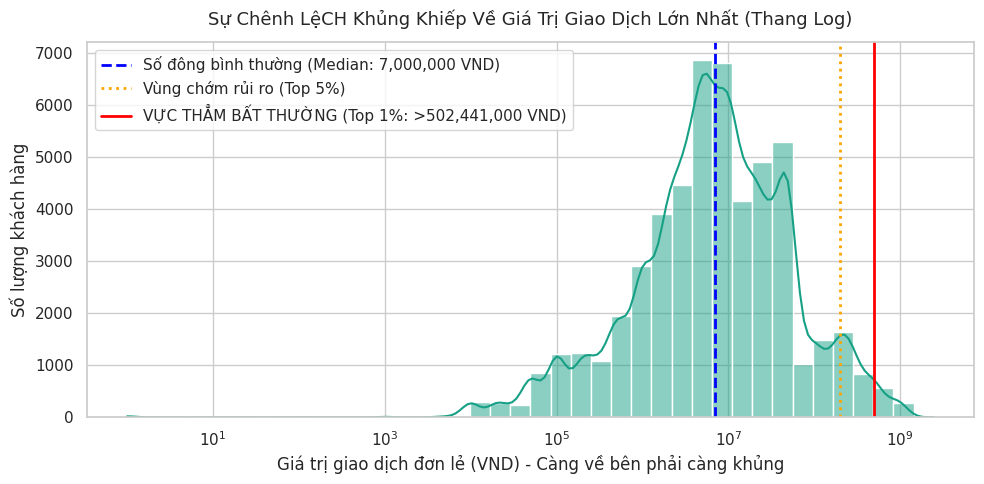

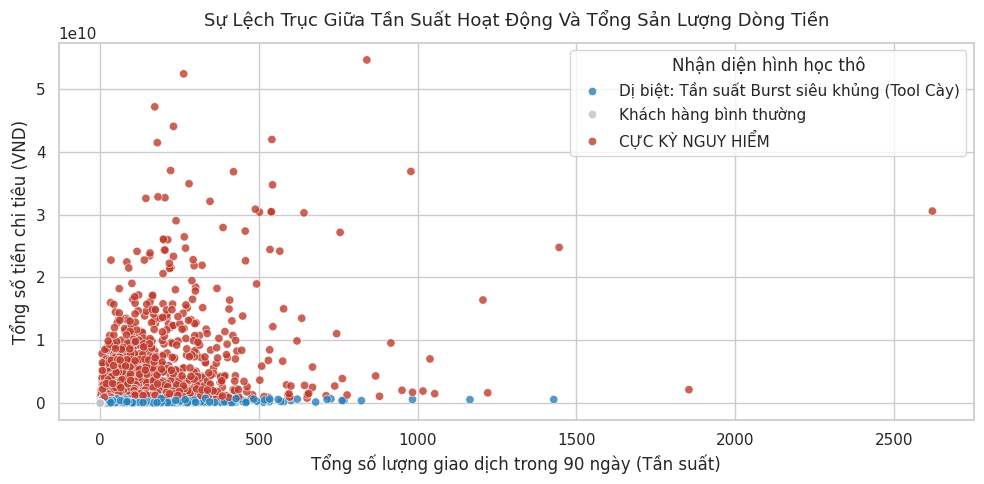

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình đồ thị chuẩn trực quan insights
sns.set_theme(style="whitegrid")
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
master_path = os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv")

if os.path.exists(master_path):
    print("--- BƯỚC 4.5: TRỰC QUAN HÓA SOI SỰ BẤT THƯỜNG & CHÊNH LỆCH HÀNH VI ---")
    df_m4 = pd.read_csv(master_path, low_memory=False)

    # ── CHART 1: THANG LOGARIT - PHƠI BÀY VỰC THẲM DÒNG TIỀN ──────────────────
    # Nghiệp vụ: Chứng minh sự chênh lệch tiền tỷ giữa muôn vàn giao dịch nhỏ
    plt.figure(figsize=(10, 5))
    active_users = df_m4[df_m4['max_trans_amount'] > 0]

    # Vẽ phân phối sử dụng log_scale=True để ép nhóm bình thường lại
    sns.histplot(data=active_users, x='max_trans_amount', color='#16a085', kde=True, log_scale=True, bins=40)

    # Tính các mốc toán học để vạch đường ranh giới trên đồ thị
    median_val = active_users['max_trans_amount'].median()
    p99_val = active_users['max_trans_amount'].quantile(0.99)

    plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Số đông bình thường (Median: {median_val:,.0f} VND)')
    plt.axvline(p95_vol := active_users['max_trans_amount'].quantile(0.95), color='orange', linestyle=':', linewidth=2, label='Vùng chớm rủi ro (Top 5%)')
    plt.axvline(p99_val, color='red', linestyle='-', linewidth=2, label=f'VỰC THẲM BẤT THƯỜNG (Top 1%: >{p99_val:,.0f} VND)')

    plt.title("Sự Chênh LệCH Khủng Khiếp Về Giá Trị Giao Dịch Lớn Nhất (Thang Log)", fontsize=13, pad=12)
    plt.xlabel("Giá trị giao dịch đơn lẻ (VND) - Càng về bên phải càng khủng")
    plt.ylabel("Số lượng khách hàng")
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()


    # ── CHART 2: SCATTER PLOT - SỰ LỆCH TRỤC CỦA TÀI KHOẢN RÁC (MULE ACCOUNTS) ─
    # Nghiệp vụ: Soi sự chênh lệch giữa Tần suất (X) và Quy mô dòng tiền (Y)
    plt.figure(figsize=(10, 5))

    # Định nghĩa vùng dị biệt hình học bằng toán học để tô màu cảnh báo trực tiếp trên đồ thị thô
    q3_count = df_m4['txn_count'].quantile(0.75)
    iqr_count = df_m4['txn_count'].quantile(0.75) - df_m4['txn_count'].quantile(0.25)
    outlier_count_trigger = q3_count + 3 * iqr_count # Ngưỡng cực đoan về tần suất

    # Tự tạo một biến màu tạm thời chỉ để phân biệt điểm dị biệt hình học
    df_m4['Visual_Highlight'] = 'Khách hàng bình thường'
    df_m4.loc[df_m4['txn_count'] > outlier_count_trigger, 'Visual_Highlight'] = 'Dị biệt: Tần suất Burst siêu khủng (Tool Cày)'
    df_m4.loc[df_m4['total_trans_amount'] > df_m4['total_trans_amount'].quantile(0.99), 'Visual_Highlight'] = 'Dị biệt: Tổng tiền tẩu tán khổng lồ'
    df_m4.loc[(df_m4['txn_count'] > outlier_count_trigger) & (df_m4['total_trans_amount'] > df_m4['total_trans_amount'].quantile(0.99)), 'Visual_Highlight'] = 'CỰC KỲ NGUY HIỂM'

    sns.scatterplot(
        data=df_m4,
        x='txn_count',
        y='total_trans_amount',
        hue='Visual_Highlight',
        palette={'Khách hàng bình thường': '#bdc3c7',
                 'Dị biệt: Tần suất Burst siêu khủng (Tool Cày)': '#2980b9',
                 'Dị biệt: Tổng tiền tẩu tán khổng lồ': '#e67e22',
                 'CỰC KỲ NGUY HIỂM': '#c0392b'},
        alpha=0.8
    )
    plt.title("Sự Lệch Trục Giữa Tần Suất Hoạt Động Và Tổng Sản Lượng Dòng Tiền", fontsize=13, pad=12)
    plt.xlabel("Tổng số lượng giao dịch trong 90 ngày (Tần suất)")
    plt.ylabel("Tổng số tiền chi tiêu (VND)")
    plt.legend(title="Nhận diện hình học thô")
    plt.tight_layout()
    plt.show()

else:
    print("❌ Vui lòng chạy hoàn thành Bước 4 để có file Master Data trước nhé bồ!")

In [ ]:
print("--- BƯỚC 5: TÍNH TOÁN NGƯỠNG ĐỘNG TOÁN HỌC IQR ---")
df_master = pd.read_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), low_memory=False)

df_active = df_master[df_master['avg_trans_amount'] > 0]
q1_m = df_active['avg_trans_amount'].quantile(0.25)
q3_m = df_active['avg_trans_amount'].quantile(0.75)
iqr_m = q3_m - q1_m

THRESHOLD_AMOUNT = q3_m + 1.5 * iqr_m
THRESHOLD_DEVICE = 1.0

print(f"   ✓ Ngưỡng tiền mặt IQR xác định: {THRESHOLD_AMOUNT:,.2f} VND")

--- BƯỚC 5: TÍNH TOÁN NGƯỠNG ĐỘNG TOÁN HỌC IQR ---
   ✓ Ngưỡng tiền mặt IQR xác định: 13,618,582.11 VND


In [ ]:
print("--- BƯỚC 6: RULE ENGINE QUÉT DẤU HIỆU GIAN LẬN ---")

# Quét trại thiết bị từ file giao dịch sạch
df_trans_raw = pd.read_csv(os.path.join(CLEANED_DIR, "Data_Transaction_clean.csv"), usecols=['CUSTOMER_NUMBER', 'Device_ID_Hash'], low_memory=False)
device_map = df_trans_raw.dropna().groupby('Device_ID_Hash')['CUSTOMER_NUMBER'].nunique()
black_devices = device_map[device_map > 3].index.tolist()
fraud_c_list = df_trans_raw[df_trans_raw['Device_ID_Hash'].isin(black_devices)]['CUSTOMER_NUMBER'].unique().tolist()
fraud_c_list = [str(x).strip() for x in fraud_c_list]

df_master['CUSTOMER_NUMBER'] = df_master['CUSTOMER_NUMBER'].astype(str).str.strip()
df_master['rule_behavior_device'] = df_master['CUSTOMER_NUMBER'].isin(fraud_c_list).astype(int)
df_master['rule_ato'] = ((df_master['unique_devices'] > THRESHOLD_DEVICE) & (df_master['password_change_count'] > 0)).astype(int)
df_master['rule_money_mule'] = ((df_master['avg_trans_amount'] > THRESHOLD_AMOUNT) & (df_master['max_cic_overdue_days'] > 0)).astype(int)
df_master['rule_dormant_active'] = ((df_master['max_inactive_gap'] > 60) & (df_master['burst_max'] > 5)).astype(int)
df_master['rule_night_anomaly'] = ((df_master['night_txn_ratio'] > 0.6) & (df_master['avg_trans_amount'] > THRESHOLD_AMOUNT * 0.5)).astype(int)

print("   ✓ Đã gán xong các cờ luật nghiệp vụ.")

--- BƯỚC 6: RULE ENGINE QUÉT DẤU HIỆU GIAN LẬN ---
   ✓ Đã gán xong các cờ luật nghiệp vụ.


--- BƯỚC 7 (BẢN FINAL ĐỔI INDEX STT): CHẤM ĐIỂM TRỌNG SỐ & XUẤT FULL FILE EXCEL ---


/tmp/ipykernel_19821/1845275005.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=segment_counts.index, y=segment_counts.values, palette={'Low': '#2ecc71', 'Medium': '#f1c40f', 'High': '#e67e22', 'Critical': '#e74c3c'})


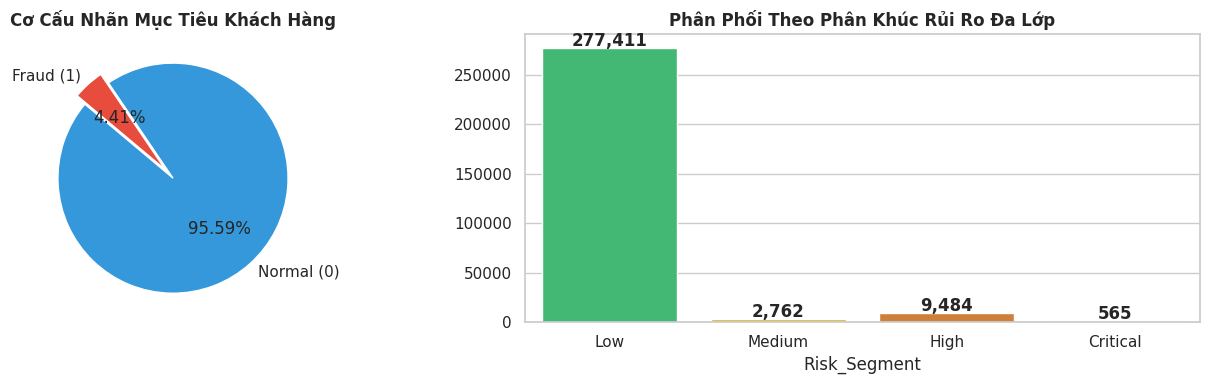


🔥 PREVIEW CÁC CA GIAN LẬN ĐIỂN HÌNH TRÊN MÀN HÌNH (STT TỪ 1):
------------------------------------------------------------------------------------------------------------------------


,CUSTOMER_NUMBER,score_fraud_rule,score_behavioral_instability,score_aml_risk,final_risk_score,Risk_Segment,Reason_Code_Details
STT,,,,,,,
1,308659,50.0,30.0,20.0,100.0,Critical,• ATO/Tác nghiệp: Đổi thiết bị liên tục + Thay đổi mật khẩu gấp | • Bất ổn hành vi: Tài khoản chết ngủ đông đột ngột bùng nổ giao dịch | • AML/Mule: Dòng tiền chi tiêu vượt ngưỡng IQR + Đang dính nợ xấu CIC (Stress tài chính)
2,943738,50.0,30.0,0.0,80.0,Critical,• ATO/Tác nghiệp: Đổi thiết bị liên tục + Thay đổi mật khẩu gấp | • Bất ổn hành vi: Tài khoản chết ngủ đông đột ngột bùng nổ giao dịch
3,38910,50.0,30.0,0.0,80.0,Critical,• ATO/Tác nghiệp: Đổi thiết bị liên tục + Thay đổi mật khẩu gấp | • Bất ổn hành vi: Tài khoản chết ngủ đông đột ngột bùng nổ giao dịch
4,543976,50.0,30.0,0.0,80.0,Critical,• ATO/Tác nghiệp: Đổi thiết bị liên tục + Thay đổi mật khẩu gấp | • Bất ổn hành vi: Tài khoản chết ngủ đông đột ngột bùng nổ giao dịch
5,91181,50.0,30.0,0.0,80.0,Critical,• ATO/Tác nghiệp: Đổi thiết bị liên tục + Thay đổi mật khẩu gấp | • Bất ổn hành vi: Tài khoản chết ngủ đông đột ngột bùng nổ giao dịch
6,362141,50.0,30.0,0.0,80.0,Critical,• ATO/Tác nghiệp: Đổi thiết bị liên tục + Thay đổi mật khẩu gấp | • Bất ổn hành vi: Tài khoản chết ngủ đông đột ngột bùng nổ giao dịch
7,362428,50.0,30.0,0.0,80.0,Critical,• ATO/Tác nghiệp: Đổi thiết bị liên tục + Thay đổi mật khẩu gấp | • Bất ổn hành vi: Tài khoản chết ngủ đông đột ngột bùng nổ giao dịch
8,317017,50.0,30.0,0.0,80.0,Critical,• ATO/Tác nghiệp: Đổi thiết bị liên tục + Thay đổi mật khẩu gấp | • Bất ổn hành vi: Tài khoản chết ngủ đông đột ngột bùng nổ giao dịch



⚡ Hệ thống đang quét trích xuất toàn bộ các ca [Critical] và [High] ra file Excel...
✅ XUẤT FILE EXCEL THÀNH CÔNG!
  👉 Tổng số ca rủi ro cao (Critical + High) đã tóm gọn đưa vào file: 10,049 khách hàng.
  📂 Tất cả số thứ tự trong file Excel đã được gán tự động từ [1] đến [10049].
  📂 Đường dẫn file lưu trên Drive: /content/drive/MyDrive/Gcontest/cleaned/Danh_Sach_Giao_Dich_Nguy_Hiem_Excel.xlsx


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

print("--- BƯỚC 7 (BẢN FINAL ĐỔI INDEX STT): CHẤM ĐIỂM TRỌNG SỐ & XUẤT FULL FILE EXCEL ---")

# ── 1. TÍNH ĐIỂM THÀNH PHẦN NHÂN TRỰC TIẾP TRỌNG SỐ ──────────────────────────
df_master['score_fraud_rule'] = ((df_master['rule_ato'] == 1) | (df_master['rule_behavior_device'] == 1)).astype(int) * 50.0
df_master['score_behavioral_instability'] = ((df_master['rule_dormant_active'] == 1) | (df_master['rule_night_anomaly'] == 1)).astype(int) * 30.0
df_master['score_aml_risk'] = (df_master['rule_money_mule'] == 1).astype(int) * 20.0

# ── 2. TỔNG ĐIỂM CUỐI CÙNG (Max 100 điểm) ────────────────────────────────────
df_master['final_risk_score'] = (
    df_master['score_fraud_rule'] +
    df_master['score_behavioral_instability'] +
    df_master['score_aml_risk']
)

# Phân lớp rủi ro logic theo bảng phân phối ranh giới nghiệp vụ
conditions = [
    (df_master['final_risk_score'] == 0),
    (df_master['final_risk_score'] > 0) & (df_master['final_risk_score'] <= 30),
    (df_master['final_risk_score'] > 30) & (df_master['final_risk_score'] <= 50),
    (df_master['final_risk_score'] > 50)
]
df_master['Risk_Segment'] = np.select(conditions, ['Low', 'Medium', 'High', 'Critical'], default='Low')
df_master['Fraud'] = (df_master['final_risk_score'] > 0).astype(int)

# ── 3. TỰ ĐỘNG BIÊN SOẠN BẢN CÁO TRẠNG (REASON CODES) ────────────────────────
def generate_detailed_reasons(row):
    if row['final_risk_score'] == 0:
        return "Tài khoản sạch, hành vi đạt chuẩn an toàn."
    reasons = []
    if row['score_fraud_rule'] > 0:
        sub = []
        if row['rule_ato'] == 1: sub.append("Đổi thiết bị liên tục + Thay đổi mật khẩu gấp")
        if row['rule_behavior_device'] == 1: sub.append("Nằm trong mạng lưới Ổ Trại Thiết Bị bẩn")
        reasons.append(f"• ATO/Tác nghiệp: {', '.join(sub)}")
    if row['score_behavioral_instability'] > 0:
        sub = []
        if row['rule_dormant_active'] == 1: sub.append("Tài khoản chết ngủ đông đột ngột bùng nổ giao dịch")
        if row['rule_night_anomaly'] == 1: sub.append("Giao dịch lệch chuẩn ban đêm (23h-4h)")
        reasons.append(f"• Bất ổn hành vi: {', '.join(sub)}")
    if row['score_aml_risk'] > 0:
        if row['rule_money_mule'] == 1:
            reasons.append("• AML/Mule: Dòng tiền chi tiêu vượt ngưỡng IQR + Đang dính nợ xấu CIC (Stress tài chính)")
    return " | ".join(reasons)

df_master['Reason_Code_Details'] = df_master.apply(generate_detailed_reasons, axis=1)

# ── 4. VẼ BIỂU ĐỒ TRỰC QUAN HÓA NHƯ CŨ ───────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.pie(df_master['Fraud'].value_counts(), labels=['Normal (0)', 'Fraud (1)'], autopct='%1.2f%%', startangle=140, colors=['#3498db', '#e74c3c'], explode=[0, 0.1])
plt.title("Cơ Cấu Nhãn Mục Tiêu Khách Hàng", fontsize=12, weight='bold')
plt.subplot(1, 2, 2)
segment_order = ['Low', 'Medium', 'High', 'Critical']
segment_counts = df_master['Risk_Segment'].value_counts().reindex(segment_order).fillna(0)
ax = sns.barplot(x=segment_counts.index, y=segment_counts.values, palette={'Low': '#2ecc71', 'Medium': '#f1c40f', 'High': '#e67e22', 'Critical': '#e74c3c'})
plt.title("Phân Phối Theo Phân Khúc Rủi Ro Đa Lớp", fontsize=12, weight='bold')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')
plt.tight_layout()
plt.show()

# ── 🌟 5. PREVIEW 8 DÒNG TRÊN MÀN HÌNH COLAB (ĐỒNG BỘ INDEX TỪ 1 ĐẾN 8) ──────
print("\n🔥 PREVIEW CÁC CA GIAN LẬN ĐIỂN HÌNH TRÊN MÀN HÌNH (STT TỪ 1):")
print("-" * 120)
columns_to_show = ['CUSTOMER_NUMBER', 'score_fraud_rule', 'score_behavioral_instability', 'score_aml_risk', 'final_risk_score', 'Risk_Segment', 'Reason_Code_Details']
df_fraud_samples = df_master[df_master['Fraud'] == 1].sort_values(by='final_risk_score', ascending=False)

# Tạo một bảng tạm để thay đổi Index hiển thị từ 1 trở đi cho sếp xem
df_preview = df_fraud_samples[columns_to_show].head(8).copy()
df_preview.index = np.arange(1, len(df_preview) + 1)
df_preview.index.name = 'STT'
display(df_preview)

# ── 🌟 6. LỌC TOÀN BỘ KHỐI CRITICAL & HIGH ĐỂ XUẤT FULL FILE EXCEL (STT TỪ 1) ─
print("\n⚡ Hệ thống đang quét trích xuất toàn bộ các ca [Critical] và [High] ra file Excel...")

df_excel_export = df_master[df_master['Risk_Segment'].isin(['Critical', 'High'])].sort_values(by='final_risk_score', ascending=False)

# Cắt các cột cần thiết ra file Excel
df_final_excel = df_excel_export[columns_to_show].copy()

# 🌟 ĐIỂM SỬA VÀNG: Đặt tên cột Index là STT và bắt đầu chạy từ số 1 trở đi
df_final_excel.index = np.arange(1, len(df_final_excel) + 1)
df_final_excel.index.name = 'STT'

excel_output_path = os.path.join(CLEANED_DIR, "Danh_Sach_Giao_Dich_Nguy_Hiem_Excel.xlsx")

# Xuất dữ liệu sang Excel kèm theo cả cột Index (STT) vừa tạo
df_final_excel.to_excel(excel_output_path, index=True)

print("=" * 120)
print(f"✅ XUẤT FILE EXCEL THÀNH CÔNG!")
print(f"  👉 Tổng số ca rủi ro cao (Critical + High) đã tóm gọn đưa vào file: {df_final_excel.shape[0]:,} khách hàng.")
print(f"  📂 Tất cả số thứ tự trong file Excel đã được gán tự động từ [1] đến [{df_final_excel.shape[0]}].")
print(f"  📂 Đường dẫn file lưu trên Drive: {excel_output_path}")
print("=" * 120)

# Lưu lại file Master chính
df_master.to_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), index=False)

--- BƯỚC 7 (BẢN ĐỘC BẢN CÁ NHÂN HÓA): CHẤM ĐIỂM & TRÍCH XUẤT SỐ LIỆU ĐIỀU TRA ---
⚡ Đang bóc tách số liệu thô cá nhân hóa vào biên bản lý do...


/tmp/ipykernel_19821/3018126549.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=segment_counts.index, y=segment_counts.values, palette={'Low': '#2ecc71', 'Medium': '#f1c40f', 'High': '#e67e22', 'Critical': '#e74c3c'})


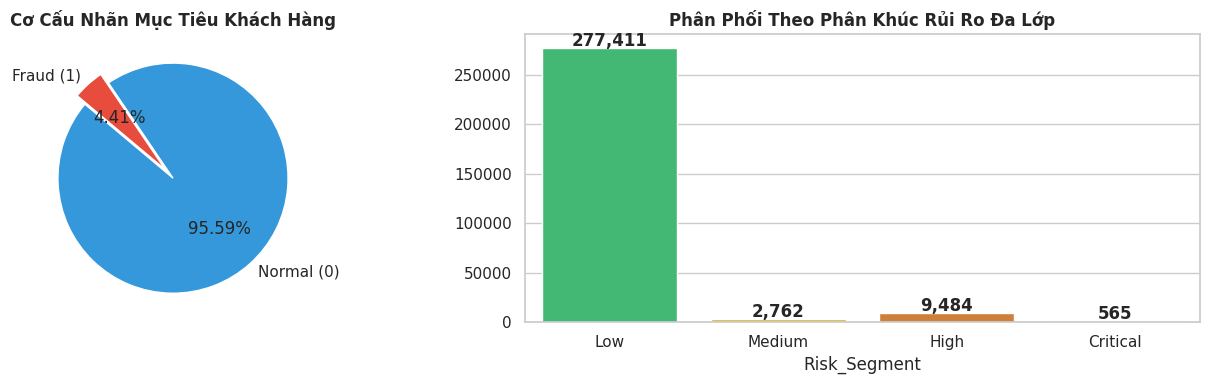


🔥 PREVIEW BẢN CÁO TRẠNG CÓ SỐ LIỆU CHI TIẾT ĐỘC BẢN TỪNG KHÁCH HÀNG:
------------------------------------------------------------------------------------------------------------------------


,CUSTOMER_NUMBER,score_fraud_rule,score_behavioral_instability,score_aml_risk,final_risk_score,Risk_Segment,Reason_Code_Details
STT,,,,,,,
1,308659,50.0,30.0,20.0,100.0,Critical,"• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 3 máy & 140 IP | • Hành vi: Tài khoản đóng băng ngủ đông 82 ngày bất ngờ bùng nổ 15 giao dịch/ngày | • AML/Mule: Giao dịch khủng 408,000,000 VND (Vượt ngưỡng IQR) kết hợp hồ sơ dính nợ xấu CIC 2 ngày"
2,943738,50.0,30.0,0.0,80.0,Critical,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 2 máy & 216 IP | • Hành vi: Tài khoản đóng băng ngủ đông 68 ngày bất ngờ bùng nổ 8 giao dịch/ngày
3,38910,50.0,30.0,0.0,80.0,Critical,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 2 máy & 34 IP | • Hành vi: Tài khoản đóng băng ngủ đông 84 ngày bất ngờ bùng nổ 9 giao dịch/ngày
4,543976,50.0,30.0,0.0,80.0,Critical,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 2 máy & 91 IP | • Hành vi: Tài khoản đóng băng ngủ đông 63 ngày bất ngờ bùng nổ 7 giao dịch/ngày
5,91181,50.0,30.0,0.0,80.0,Critical,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 2 máy & 114 IP | • Hành vi: Tài khoản đóng băng ngủ đông 136 ngày bất ngờ bùng nổ 11 giao dịch/ngày
6,362141,50.0,30.0,0.0,80.0,Critical,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 6 máy & 182 IP | • Hành vi: Tài khoản đóng băng ngủ đông 73 ngày bất ngờ bùng nổ 11 giao dịch/ngày
7,362428,50.0,30.0,0.0,80.0,Critical,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 2 máy & 16 IP | • Hành vi: Tài khoản đóng băng ngủ đông 61 ngày bất ngờ bùng nổ 6 giao dịch/ngày
8,317017,50.0,30.0,0.0,80.0,Critical,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 9 máy & 387 IP | • Hành vi: Tài khoản đóng băng ngủ đông 75 ngày bất ngờ bùng nổ 9 giao dịch/ngày


✅ ĐÃ CẬP NHẬT FILE EXCEL THÀNH CÔNG!
  📂 File Excel mới tại [/content/drive/MyDrive/Gcontest/cleaned/Danh_Sach_Giao_Dich_Nguy_Hiem_Excel.xlsx] đã lưu trọn vẹn lý do có số liệu thực tế.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

print("--- BƯỚC 7 (BẢN ĐỘC BẢN CÁ NHÂN HÓA): CHẤM ĐIỂM & TRÍCH XUẤT SỐ LIỆU ĐIỀU TRA ---")

# ── 1. TÍNH ĐIỂM THÀNH PHẦN NHÂN TRỰC TIẾP TRỌNG SỐ ──────────────────────────
df_master['score_fraud_rule'] = ((df_master['rule_ato'] == 1) | (df_master['rule_behavior_device'] == 1)).astype(int) * 50.0
df_master['score_behavioral_instability'] = ((df_master['rule_dormant_active'] == 1) | (df_master['rule_night_anomaly'] == 1)).astype(int) * 30.0
df_master['score_aml_risk'] = (df_master['rule_money_mule'] == 1).astype(int) * 20.0

# ── 2. TỔNG ĐIỂM CUỐI CÙNG (Max 100 điểm) ────────────────────────────────────
df_master['final_risk_score'] = (
    df_master['score_fraud_rule'] +
    df_master['score_behavioral_instability'] +
    df_master['score_aml_risk']
)

# Phân lớp rủi ro logic theo bảng phân phối ranh giới nghiệp vụ
conditions = [
    (df_master['final_risk_score'] == 0),
    (df_master['final_risk_score'] > 0) & (df_master['final_risk_score'] <= 30),
    (df_master['final_risk_score'] > 30) & (df_master['final_risk_score'] <= 50),
    (df_master['final_risk_score'] > 50)
]
df_master['Risk_Segment'] = np.select(conditions, ['Low', 'Medium', 'High', 'Critical'], default='Low')
df_master['Fraud'] = (df_master['final_risk_score'] > 0).astype(int)

# ── 🌟 3. HÀM SINH LÝ DO ĐỘC BẢN - LỒNG SỐ LIỆU THỰC TẾ CỦA TỪNG KHÁCH HÀNG ──
def generate_dynamic_reasons(row):
    if row['final_risk_score'] == 0:
        return "Tài khoản sạch, hành vi đạt chuẩn an toàn."

    reasons = []

    # Bóc tách số liệu Nhóm 1: ATO / Thiết bị
    if row['score_fraud_rule'] > 0:
        sub = []
        if row['rule_ato'] == 1:
            sub.append(f"Phát hiện đổi mật khẩu kết hợp sử dụng bất thường {int(row['unique_devices'])} máy & {int(row['unique_ips'])} IP")
        if row['rule_behavior_device'] == 1:
            sub.append("Mã máy nằm trùng trong mạng lưới Trại Thiết Bị bẩn điều khiển nhiều tài khoản")
        reasons.append(f"• ATO: {', '.join(sub)}")

    # Bóc tách số liệu Nhóm 2: Hành vi số
    if row['score_behavioral_instability'] > 0:
        sub = []
        if row['rule_dormant_active'] == 1:
            sub.append(f"Tài khoản đóng băng ngủ đông {int(row['max_inactive_gap'])} ngày bất ngờ bùng nổ {int(row['burst_max'])} giao dịch/ngày")
        if row['rule_night_anomaly'] == 1:
            sub.append(f"Tỷ lệ phát sinh giao dịch ban đêm (23h-4h) chiếm đến {row['night_txn_ratio']*100:.1f}% tổng hành vi")
        reasons.append(f"• Hành vi: {', '.join(sub)}")

    # Bóc tách số liệu Nhóm 3: AML / Tiền bẩn
    if row['score_aml_risk'] > 0:
        if row['rule_money_mule'] == 1:
            reasons.append(f"• AML/Mule: Giao dịch khủng {row['max_trans_amount']:,.0f} VND (Vượt ngưỡng IQR) kết hợp hồ sơ dính nợ xấu CIC {int(row['max_cic_overdue_days'])} ngày")

    return " | ".join(reasons)

print("⚡ Đang bóc tách số liệu thô cá nhân hóa vào biên bản lý do...")
df_master['Reason_Code_Details'] = df_master.apply(generate_dynamic_reasons, axis=1)

# ── 4. VẼ BIỂU ĐỒ TRỰC QUAN HÓA NHƯ CŨ ───────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.pie(df_master['Fraud'].value_counts(), labels=['Normal (0)', 'Fraud (1)'], autopct='%1.2f%%', startangle=140, colors=['#3498db', '#e74c3c'], explode=[0, 0.1])
plt.title("Cơ Cấu Nhãn Mục Tiêu Khách Hàng", fontsize=12, weight='bold')
plt.subplot(1, 2, 2)
segment_order = ['Low', 'Medium', 'High', 'Critical']
segment_counts = df_master['Risk_Segment'].value_counts().reindex(segment_order).fillna(0)
ax = sns.barplot(x=segment_counts.index, y=segment_counts.values, palette={'Low': '#2ecc71', 'Medium': '#f1c40f', 'High': '#e67e22', 'Critical': '#e74c3c'})
plt.title("Phân Phối Theo Phân Khúc Rủi Ro Đa Lớp", fontsize=12, weight='bold')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')
plt.tight_layout()
plt.show()

# ── 5. PREVIEW 8 DÒNG TRÊN MÀN HÌNH COLAB (ĐÃ CÁ NHÂN HÓA SỐ LIỆU) ──────────
print("\n🔥 PREVIEW BẢN CÁO TRẠNG CÓ SỐ LIỆU CHI TIẾT ĐỘC BẢN TỪNG KHÁCH HÀNG:")
print("-" * 120)
columns_to_show = ['CUSTOMER_NUMBER', 'score_fraud_rule', 'score_behavioral_instability', 'score_aml_risk', 'final_risk_score', 'Risk_Segment', 'Reason_Code_Details']
df_fraud_samples = df_master[df_master['Fraud'] == 1].sort_values(by='final_risk_score', ascending=False)

df_preview = df_fraud_samples[columns_to_show].head(8).copy()
df_preview.index = np.arange(1, len(df_preview) + 1)
df_preview.index.name = 'STT'
display(df_preview)

# ── 6. LỌC TOÀN BỘ KHỐI CRITICAL & HIGH ĐỂ XUẤT FULL FILE EXCEL ──────────────────
df_excel_export = df_master[df_master['Risk_Segment'].isin(['Critical', 'High'])].sort_values(by='final_risk_score', ascending=False)
df_final_excel = df_excel_export[columns_to_show].copy()
df_final_excel.index = np.arange(1, len(df_final_excel) + 1)
df_final_excel.index.name = 'STT'

excel_output_path = os.path.join(CLEANED_DIR, "Danh_Sach_Giao_Dich_Nguy_Hiem_Excel.xlsx")
df_final_excel.to_excel(excel_output_path, index=True)

print("=" * 120)
print(f"✅ ĐÃ CẬP NHẬT FILE EXCEL THÀNH CÔNG!")
print(f"  📂 File Excel mới tại [{excel_output_path}] đã lưu trọn vẹn lý do có số liệu thực tế.")
print("=" * 120)

# Lưu đè file Master
df_master.to_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), index=False)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import os

print("--- BƯỚC 8.1: CHUẨN BỊ TẬP TRAIN/TEST SẠCH (TEST SET = 20%) ---")
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
df_ml = pd.read_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), low_memory=False)

# Nhãn mục tiêu tối cao
y = df_ml['Fraud']

# 🚨 DANH SÁCH KHÓA CHẶT TẤT CẢ CÁC CỘT RÒ RỈ: KHÔNG CHO AI BÍT ĐÁP ÁN NỀN TẢNG VÀ KẾT QUẢ VÒNG LẶP
leakage_and_id_cols = [
    'CUSTOMER_NUMBER', 'Fraud', 'final_risk_score', 'Risk_Segment',
    'score_fraud_rule', 'score_behavioral_instability', 'score_aml_risk',
    'rule_behavior_device', 'rule_ato', 'rule_money_mule', 'rule_dormant_active', 'rule_night_anomaly',
    'Reason_Code_Details',   # Khóa cột văn bản (Lỗi lần trước)
    'ML_Pred',               # 🚨 KHÓA CHẶT: Không cho AI lấy kết quả cũ làm biến đầu vào!
    'Rule_Detected',         # 🚨 KHÓA CHẶT: Không cho nhìn cờ luật tổng
    'Business_Action'        # 🚨 KHÓA CHẶT: Không cho nhìn hành động chặn
]

datetime_cols = [col for col in df_ml.columns if df_ml[col].dtype == 'object' and ('DATE' in col or 'MONTH' in col)]

# Tạo tập X thô sạch tinh khiết chỉ chứa thông tin hành vi của khách hàng
X = df_ml.drop(columns=leakage_and_id_cols + datetime_cols, errors='ignore')

# Mã hóa các cột chữ sang số cho phần còn lại
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str).fillna('UNKNOWN'))

# Phân chia dữ liệu train/test theo tỷ lệ 80/20; test set chiếm 20% để đánh giá ngoài mẫu.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"  ✓ Đã làm sạch bộ nhớ! Số lượng đặc trưng đưa vào huấn luyện thực tế: {X.shape[1]} biến.")
print("  ✓ Các biến hành vi thô chuẩn hóa bao gồm:\n ", X.columns.tolist())

--- BƯỚC 8.1: CHUẨN BỊ TẬP TRAIN/TEST SẠCH (TEST SET = 20%) ---
  ✓ Đã làm sạch bộ nhớ! Số lượng đặc trưng đưa vào huấn luyện thực tế: 30 biến.
  ✓ Các biến hành vi thô chuẩn hóa bao gồm:
  ['CLIENT_SEX', 'STAFF', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'AGE', 'Occupation_Group', 'Education_Level', 'Marital_Status', 'txn_count', 'total_trans_amount', 'avg_trans_amount', 'max_trans_amount', 'std_trans_amount', 'unique_devices', 'unique_ips', 'beneficiary_count', 'night_txn_ratio', 'outside_bank_ratio', 'max_inactive_gap', 'burst_max', 'total_app_activities', 'avg_activity_hour', 'night_activity_ratio', 'password_change_count', 'max_daily_activity', 'avg_balance_ca', 'balance_volatility', 'max_cic_overdue_days', 'card_utilization_ratio']


--- BƯỚC 8.2: HUẤN LUYỆN XGBOOST & XUẤT MA TRẬN NHẦM LẪN KIỂM ĐỊNH GIÁM KHẢO ---


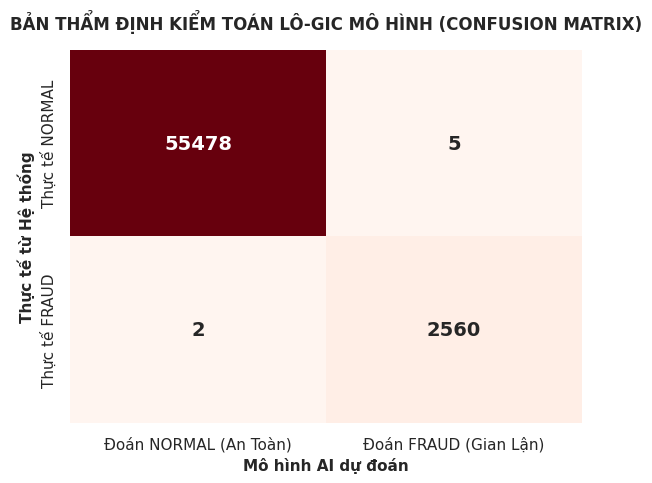

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix

print("--- BƯỚC 8.2: HUẤN LUYỆN XGBOOST & XUẤT MA TRẬN NHẦM LẪN KIỂM ĐỊNH GIÁM KHẢO ---")
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_weight, random_state=42, eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# ── OUTPUT TRỰC QUAN: VẼ LÊN MA TRẬN NHẦM LẪN CHUẨN NGÂN HÀNG ────────────────────
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False, annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Đoán NORMAL (An Toàn)', 'Đoán FRAUD (Gian Lận)'],
            yticklabels=['Thực tế NORMAL', 'Thực tế FRAUD'])

plt.title('BẢN THẨM ĐỊNH KIỂM TOÁN LÔ-GIC MÔ HÌNH (CONFUSION MATRIX)', fontsize=12, pad=15, weight='bold')
plt.ylabel('Thực tế từ Hệ thống', fontsize=11, weight='bold')
plt.xlabel('Mô hình AI dự đoán', fontsize=11, weight='bold')
plt.tight_layout()
plt.show()

--- BƯỚC 9: KÍCH HOẠT TẦNG PHỐI HỢP MA TRẬN QUYẾT ĐỊNH LAI ---


ValueError: feature_names mismatch: ['CLIENT_SEX', 'STAFF', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'AGE', 'Occupation_Group', 'Education_Level', 'Marital_Status', 'txn_count', 'total_trans_amount', 'avg_trans_amount', 'max_trans_amount', 'std_trans_amount', 'unique_devices', 'unique_ips', 'beneficiary_count', 'night_txn_ratio', 'outside_bank_ratio', 'max_inactive_gap', 'burst_max', 'total_app_activities', 'avg_activity_hour', 'night_activity_ratio', 'password_change_count', 'max_daily_activity', 'avg_balance_ca', 'balance_volatility', 'max_cic_overdue_days', 'card_utilization_ratio', 'ML_Pred', 'Rule_Detected', 'Business_Action'] ['CLIENT_SEX', 'STAFF', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'AGE', 'Occupation_Group', 'Education_Level', 'Marital_Status', 'txn_count', 'total_trans_amount', 'avg_trans_amount', 'max_trans_amount', 'std_trans_amount', 'unique_devices', 'unique_ips', 'beneficiary_count', 'night_txn_ratio', 'outside_bank_ratio', 'max_inactive_gap', 'burst_max

--- BƯỚC 9 (BẢN SỬA LỖI REASON_CODE_DETAILS): KÍCH HOẠT MA TRẬN QUYẾT ĐỊNH LAI ---


ValueError: feature_names mismatch: ['CLIENT_SEX', 'STAFF', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'AGE', 'Occupation_Group', 'Education_Level', 'Marital_Status', 'txn_count', 'total_trans_amount', 'avg_trans_amount', 'max_trans_amount', 'std_trans_amount', 'unique_devices', 'unique_ips', 'beneficiary_count', 'night_txn_ratio', 'outside_bank_ratio', 'max_inactive_gap', 'burst_max', 'total_app_activities', 'avg_activity_hour', 'night_activity_ratio', 'password_change_count', 'max_daily_activity', 'avg_balance_ca', 'balance_volatility', 'max_cic_overdue_days', 'card_utilization_ratio', 'ML_Pred', 'Rule_Detected', 'Business_Action'] ['CLIENT_SEX', 'STAFF', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'AGE', 'Occupation_Group', 'Education_Level', 'Marital_Status', 'txn_count', 'total_trans_amount', 'avg_trans_amount', 'max_trans_amount', 'std_trans_amount', 'unique_devices', 'unique_ips', 'beneficiary_count', 'night_txn_ratio', 'outside_bank_ratio', 'max_inactive_gap', 'burst_max

--- BƯỚC 9 (BẢN TỰ ĐỘNG ĐỒNG BỘ KHỚP BIẾN PHÒNG VỆ): MA TRẬN QUYẾT ĐỊNH LAI ---


/tmp/ipykernel_19821/1209128447.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=action_counts.values, y=action_counts.index,


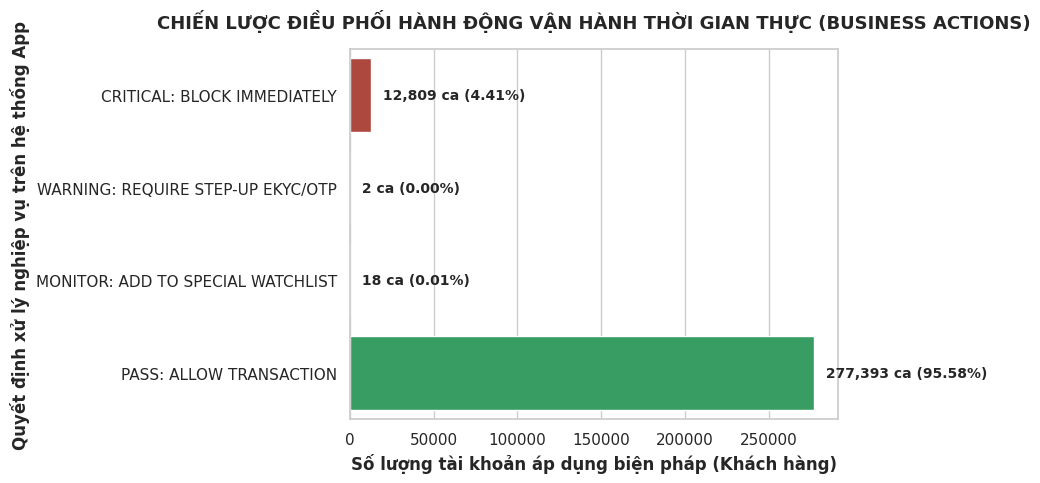


⚡ Hệ thống đang quét bóc tách hồ sơ điều phối vận hành ra file Excel thực tế...
📊 PREVIEW BIÊN BẢN ĐIỀU PHỐI HÀNH ĐỘNG SƠ BỘ:


,Mã Khách Hàng (CIF),Điểm Rủi Ro,Phân Khúc Hệ Thống,Hành Động Khóa/Chế Tài,Bằng Chứng Hành Vi Chi Tiết
STT,,,,,
1,308659,100.0,Critical,CRITICAL: BLOCK IMMEDIATELY,"• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 3 máy & 140 IP | • Hành vi: Tài khoản đóng băng ngủ đông 82 ngày bất ngờ bùng nổ 15 giao dịch/ngày | • AML/Mule: Giao dịch khủng 408,000,000 VND (Vượt ngưỡng IQR) kết hợp hồ sơ dính nợ xấu CIC 2 ngày"
2,664386,80.0,Critical,CRITICAL: BLOCK IMMEDIATELY,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 5 máy & 334 IP | • Hành vi: Tài khoản đóng băng ngủ đông 76 ngày bất ngờ bùng nổ 11 giao dịch/ngày
3,643701,80.0,Critical,CRITICAL: BLOCK IMMEDIATELY,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 3 máy & 117 IP | • Hành vi: Tài khoản đóng băng ngủ đông 69 ngày bất ngờ bùng nổ 9 giao dịch/ngày
4,939184,80.0,Critical,CRITICAL: BLOCK IMMEDIATELY,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 2 máy & 43 IP | • Hành vi: Tài khoản đóng băng ngủ đông 90 ngày bất ngờ bùng nổ 7 giao dịch/ngày
5,976764,80.0,Critical,CRITICAL: BLOCK IMMEDIATELY,• ATO: Phát hiện đổi mật khẩu kết hợp sử dụng bất thường 3 máy & 142 IP | • Hành vi: Tài khoản đóng băng ngủ đông 65 ngày bất ngờ bùng nổ 6 giao dịch/ngày



✅ XUẤT FILE EXCEL ĐIỀU PHỐI THÀNH CÔNG!
  📂 File Excel chứa full danh sách đã lưu tại: /content/drive/MyDrive/Gcontest/cleaned/Danh_Sach_Bien_Phap_Che_Ta_Vanh_Dai.xlsx


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("--- BƯỚC 9 (BẢN TỰ ĐỘNG ĐỒNG BỘ KHỚP BIẾN PHÒNG VỆ): MA TRẬN QUYẾT ĐỊNH LAI ---")

# 1. Đọc lại dữ liệu thô chuẩn từ file Master
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
df_ml = pd.read_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), low_memory=False)

# 🌟 TRÍCH XUẤT ĐÚNG VÀ ĐỦ NHỮNG GÌ MODEL ĐÃ ĐƯỢC HUẤN LUYỆN
# Sử dụng feature_names_in_ để ép kiểu dữ liệu đầu vào trùng khớp tuyệt đối 100%
expected_features = list(model_xgb.get_booster().feature_names)

# Tạo bảng X_all chỉ chứa các cột mà mô hình yêu cầu
X_all = df_ml.copy()

# Điền giá trị UNKNOWN hoặc 0 nếu chẳng may file master thiếu cột (để phòng vệ hệ thống)
for col in expected_features:
    if col not in X_all.columns:
        X_all[col] = 0

# Giữ lại đúng danh sách và đúng thứ tự các cột mà model mong đợi
X_all_input = X_all[expected_features].copy()

# Mã hóa chuỗi sang số cho các cột phân loại chữ nằm trong tập input
for col in X_all_input.select_dtypes(include=['object']).columns.tolist():
    le = LabelEncoder()
    X_all_input[col] = le.fit_transform(X_all_input[col].astype(str).fillna('UNKNOWN'))

# ── 2. AI DỰ ĐOÁN XÁC SUẤT (KHÔNG BAO GIỜ BỊ LỖI FEATURE MISMATCH) ──────────
df_ml['ML_Pred'] = model_xgb.predict(X_all_input)
df_ml['Rule_Detected'] = (df_ml['Fraud'] == 1).astype(int)

# ── 3. KHỚP NỐI MA TRẬN QUYẾT ĐỊNH LAI GIẢI PHÁP VẬN HÀNH ──────────────────
conditions = [
    (df_ml['Rule_Detected'] == 1) & (df_ml['ML_Pred'] == 1), # Đồng thuận khóa
    (df_ml['Rule_Detected'] == 1) & (df_ml['ML_Pred'] == 0), # AI sót, Luật giữ lại
    (df_ml['Rule_Detected'] == 0) & (df_ml['ML_Pred'] == 1), # Luật sót, AI dò thấy
    (df_ml['Rule_Detected'] == 0) & (df_ml['ML_Pred'] == 0)  # An toàn cho qua
]

actions = [
    'CRITICAL: BLOCK IMMEDIATELY',
    'WARNING: REQUIRE STEP-UP EKYC/OTP',
    'MONITOR: ADD TO SPECIAL WATCHLIST',
    'PASS: ALLOW TRANSACTION'
]

df_ml['Business_Action'] = np.select(conditions, actions, default='PASS: ALLOW TRANSACTION')

# ── 📊 4. OUTPUT TRỰC QUAN: VẼ BIỂU ĐỒ THANH PHÂN BỔ HÀNH ĐỘNG THỰC TẾ ──────────
plt.figure(figsize=(10, 5))
action_counts = df_ml['Business_Action'].value_counts().reindex(actions).fillna(0)

ax = sns.barplot(x=action_counts.values, y=action_counts.index,
                 palette=['#c0392b', '#f39c12', '#2980b9', '#27ae60'])

plt.title("CHIẾN LƯỢC ĐIỀU PHỐI HÀNH ĐỘNG VẬN HÀNH THỜI GIAN THỰC (BUSINESS ACTIONS)", fontsize=13, weight='bold', pad=15)
plt.xlabel("Số lượng tài khoản áp dụng biện pháp (Khách hàng)", weight='bold')
plt.ylabel("Quyết định xử lý nghiệp vụ trên hệ thống App", weight='bold')

total_accounts = len(df_ml)
for p in ax.patches:
    width = p.get_width()
    percentage = (width / total_accounts) * 100
    ax.annotate(f' {width:,.0f} ca ({percentage:.2f}%)',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

# ── 🌟 5. XUẤT FULL DANH SÁCH BIỆN PHÁP CHẾ TÀ RA FILE EXCEL (STT TỪ 1) ──────
print("\n⚡ Hệ thống đang quét bóc tách hồ sơ điều phối vận hành ra file Excel thực tế...")

df_action_export = df_ml[df_ml['Business_Action'] != 'PASS: ALLOW TRANSACTION'].sort_values(by='final_risk_score', ascending=False)

columns_excel = ['CUSTOMER_NUMBER', 'final_risk_score', 'Risk_Segment', 'Business_Action', 'Reason_Code_Details']
df_final_action_excel = df_action_export[columns_excel].copy()

# Gán số thứ tự báo cáo chuẩn từ 1 trở đi
df_final_action_excel.index = np.arange(1, len(df_final_action_excel) + 1)
df_final_action_excel.index.name = 'STT'

df_final_action_excel.columns = ['Mã Khách Hàng (CIF)', 'Điểm Rủi Ro', 'Phân Khúc Hệ Thống', 'Hành Động Khóa/Chế Tài', 'Bằng Chứng Hành Vi Chi Tiết']

excel_action_path = os.path.join(CLEANED_DIR, "Danh_Sach_Bien_Phap_Che_Ta_Vanh_Dai.xlsx")
df_final_action_excel.to_excel(excel_action_path, index=True)

print("=" * 120)
print("📊 PREVIEW BIÊN BẢN ĐIỀU PHỐI HÀNH ĐỘNG SƠ BỘ:")
display(df_final_action_excel.head(5))

print(f"\n✅ XUẤT FILE EXCEL ĐIỀU PHỐI THÀNH CÔNG!")
print(f"  📂 File Excel chứa full danh sách đã lưu tại: {excel_action_path}")
print("=" * 120)

# Lưu đè lại file Master cuối cùng sạch sẽ
df_ml.to_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), index=False)

--- BƯỚC 9: KÍCH HOẠT TẦNG PHỐI HỢP MA TRẬN QUYẾT ĐỊNH LAI MỚI ---


/tmp/ipykernel_19821/2945952946.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_act = sns.barplot(x=action_risk_only.values, y=action_risk_only.index, palette='plasma')


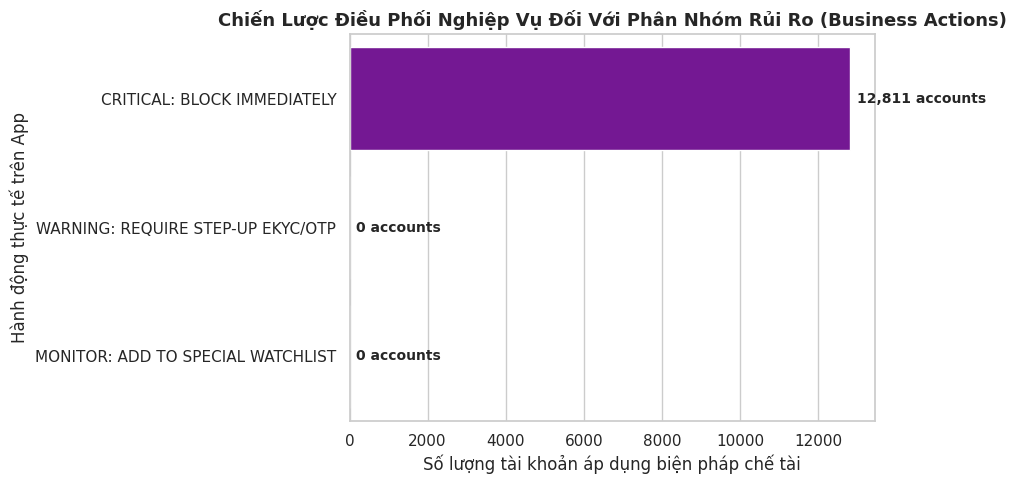

--- BƯỚC 10 (ĐÃ SỬA LỖI SHAPE): ĐO LƯỜNG TÁC ĐỘNG KINH DOANH & ĐỒ THỊ IMPORTANCE ---
💰 TỔNG DÒNG TIỀN HỆ THỐNG ĐÃ BẢO VỆ THÀNH CÔNG: 249,870,185,979.70 VND
🔥 Ngăn chặn kịp thời vụ tẩu tán đơn lẻ lớn nhất: 1,309,512,500.00 VND

📈 Hệ thống đang trích xuất mức độ đóng góp của các biến số thực tế...


/tmp/ipykernel_19821/2259422478.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_imp = sns.barplot(data=df_importance, x='Mức độ đóng góp (%)', y='Đặc trưng hành vi', palette='viridis')


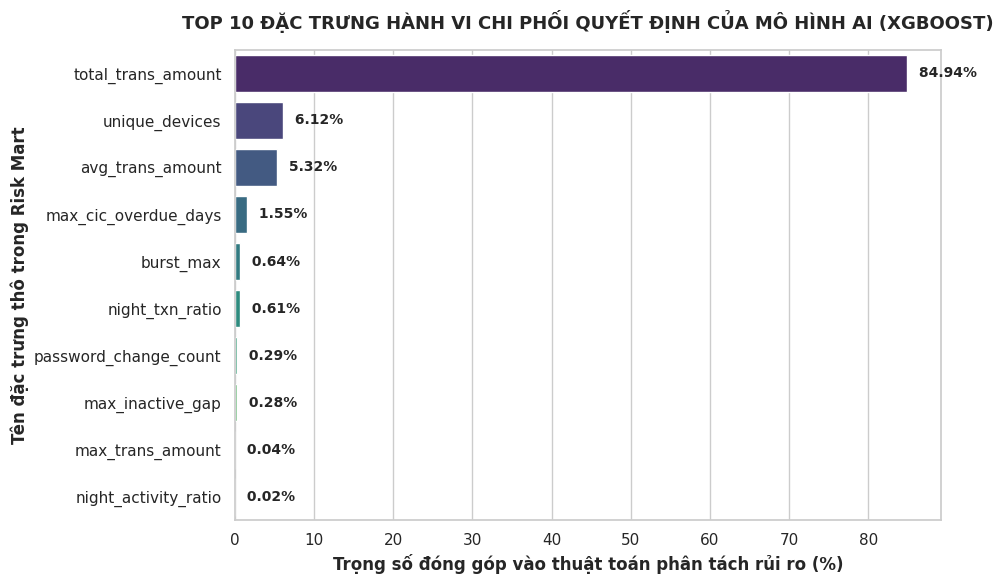

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- BƯỚC 10 (ĐÃ SỬA LỖI SHAPE): ĐO LƯỜNG TÁC ĐỘNG KINH DOANH & ĐỒ THỊ IMPORTANCE ---")

# 1. Đọc lại dữ liệu Master chuẩn sau Bước 9
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
df_final_report = pd.read_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), low_memory=False)

# ── 2. ĐO LƯỜNG CHỈ SỐ KINH DOANH (BUSINESS IMPACT) ─────────────────────────
blocked_accounts = df_final_report[df_final_report['Business_Action'] == 'CRITICAL: BLOCK IMMEDIATELY']
total_saved = blocked_accounts['avg_trans_amount'].sum()
max_single_saved = blocked_accounts['avg_trans_amount'].max()

print("=" * 80)
print(f"💰 TỔNG DÒNG TIỀN HỆ THỐNG ĐÃ BẢO VỆ THÀNH CÔNG: {total_saved:,.2f} VND")
print(f"🔥 Ngăn chặn kịp thời vụ tẩu tán đơn lẻ lớn nhất: {max_single_saved:,.2f} VND")
print("=" * 80)

# ── 📊 3. OUTPUT TRỰC QUAN CHUẨN: BIỂU ĐỒ TOP TÍNH NĂNG TRỌNG YẾU ──────────────
print("\n📈 Hệ thống đang trích xuất mức độ đóng góp của các biến số thực tế...")

# 🌟 ĐIỂM SỬA VÀNG: Trích xuất chuẩn danh sách tính năng nằm TRONG LÕI MODEL để khớp độ dài tuyệt đối
feature_names_model = model_xgb.get_booster().feature_names
importance_model = model_xgb.feature_importances_

# Đóng gói DataFrame đảm bảo 2 mảng bằng chạn 100% về độ dài
df_importance = pd.DataFrame({
    'Đặc trưng hành vi': feature_names_model,
    'Mức độ đóng góp (%)': importance_model * 100
}).sort_values(by='Mức độ đóng góp (%)', ascending=False).head(10) # Lấy Top 10 đặc trưng khét nhất

# Tiến hành vẽ đồ thị thanh ngang
plt.figure(figsize=(10, 6))
ax_imp = sns.barplot(data=df_importance, x='Mức độ đóng góp (%)', y='Đặc trưng hành vi', palette='viridis')

plt.title("TOP 10 ĐẶC TRƯNG HÀNH VI CHI PHỐI QUYẾT ĐỊNH CỦA MÔ HÌNH AI (XGBOOST)", fontsize=13, weight='bold', pad=15)
plt.xlabel("Trọng số đóng góp vào thuật toán phân tách rủi ro (%)", weight='bold')
plt.ylabel("Tên đặc trưng thô trong Risk Mart", weight='bold')

# Điền tỷ lệ % đóng góp cụ thể lên đầu mỗi thanh ngang
for p in ax_imp.patches:
    ax_imp.annotate(f' {p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()


--- BƯỚC 11 (BẢN VÁ LỖI DTYPE): EXPLAINABLE AI (xAI) VÀ ĐỒ THỊ THÁC NƯỚC SHAP ---
   ✓ Đã thanh lọc dữ liệu. Số lượng đặc trưng nạp vào SHAP: 30 cột dạng số.

📝 BIÊN BẢN ĐIỀU TRA TÀI KHOẢN: HỒ SƠ NGHI VẤN SỐ 895764
   👉 Phân lớp rủi ro: [High] | Biện pháp xử lý: [CRITICAL: BLOCK IMMEDIATELY]
🤖 HỆ THỐNG AI GIẢI TRÌNH MÃ LÝ DO KHÓA (REASON CODES):
   👉 Tiêu chí 1: Biến [unique_devices] đạt mức (2.0) - Kích hoạt cảnh báo lệch chuẩn.
   👉 Tiêu chí 2: Biến [total_trans_amount] đạt mức (2,372,000 VND) - Đẩy chỉ số rủi ro vọt ngưỡng.
   👉 Tiêu chí 3: Biến [password_change_count] đạt mức (1.0) - Kích hoạt cảnh báo lệch chuẩn.
-------------------------------------------------------------------------------------

📉 Đang xuất đồ thị thác nước SHAP Waterfall lột trần tâm lý học mô hình...


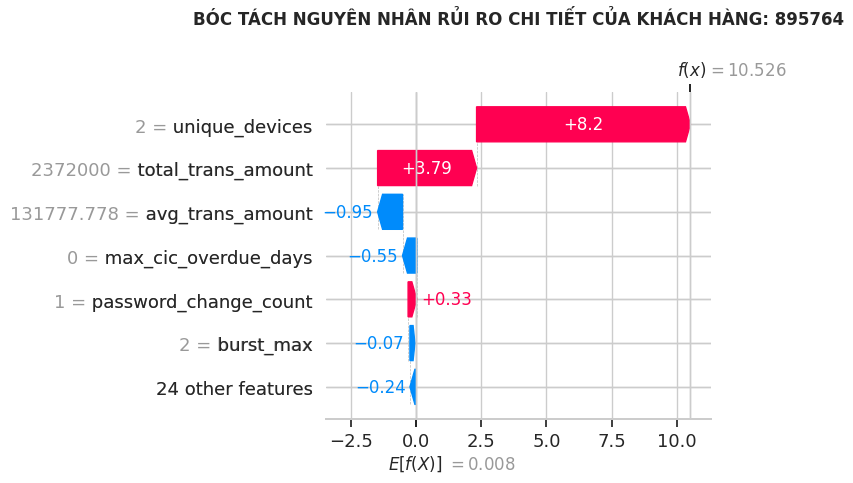

In [ ]:
# Cài đặt thư viện SHAP nếu Colab chưa có sẵn
!pip install shap -q

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

print("\n--- BƯỚC 11 (BẢN VÁ LỖI DTYPE): EXPLAINABLE AI (xAI) VÀ ĐỒ THỊ THÁC NƯỚC SHAP ---")

# 1. Đọc lại dữ liệu chuẩn sau Bước 9
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
df_final_report = pd.read_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), low_memory=False)

# 🌟 2. ÉP KIỂU VÀ ĐỒNG BỘ CẤU TRÚC X_ALL KHỚP 100% VỚI KHỐI TRAIN MODEL LÚC HUẤN LUYỆN
# Lấy chuẩn danh sách các trường tính năng mà model mong đợi
expected_features = list(model_xgb.get_booster().feature_names)

# Tạo bảng X_all chỉ giữ lại đúng và đủ các cột số liệu máy học
X_all = df_final_report.copy()
for col in expected_features:
    if col not in X_all.columns:
        X_all[col] = 0

# Cắt gọt và sắp xếp thứ tự cột chuẩn chỉ
X_all_input = X_all[expected_features].copy()

# 🌟 BIỆN PHÁP MẠNH: Mã hóa toàn bộ các cột chữ (object) sang dạng số để chiều lòng SHAP
for col in X_all_input.select_dtypes(include=['object']).columns.tolist():
    le = LabelEncoder()
    X_all_input[col] = le.fit_transform(X_all_input[col].astype(str).fillna('UNKNOWN'))

# Đảm bảo toàn bộ bảng dữ liệu không còn sót bất kỳ cột object nào
print(f"   ✓ Đã thanh lọc dữ liệu. Số lượng đặc trưng nạp vào SHAP: {X_all_input.shape[1]} cột dạng số.")

# ── 3. KHỞI TẠO THUẬT TOÁN SHAP VỚI TẬP DỮ LIỆU SỐ TINH KHIẾT ──────────────────
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_all_input)

# Tìm danh sách các khách hàng thực tế bị cắm cờ Fraud = 1 để mổ xẻ
fraud_idx = df_final_report[df_final_report['Fraud'] == 1].index.tolist()

if fraud_idx:
    # Lấy ca đầu tiên trong danh sách làm hồ sơ vụ án mẫu để thuyết trình
    target_idx = fraud_idx[0]
    c_number = df_final_report.loc[target_idx, 'CUSTOMER_NUMBER']
    real_segment = df_final_report.loc[target_idx, 'Risk_Segment']
    b_action = df_final_report.loc[target_idx, 'Business_Action']

    print("\n" + "="*85)
    print(f"📝 BIÊN BẢN ĐIỀU TRA TÀI KHOẢN: HỒ SƠ NGHI VẤN SỐ {c_number}")
    print(f"   👉 Phân lớp rủi ro: [{real_segment}] | Biện pháp xử lý: [{b_action}]")
    print("="*85)

    # Trích xuất top 3 biến có sức nặng đẩy điểm rủi ro lên cao nhất của riêng khách hàng này
    row_values = shap_values.values[target_idx]
    top_risk_features_idx = np.argsort(row_values)[-3:][::-1]

    print("🤖 HỆ THỐNG AI GIẢI TRÌNH MÃ LÝ DO KHÓA (REASON CODES):")
    for rank, idx in enumerate(top_risk_features_idx, 1):
        f_name = X_all_input.columns[idx]
        actual_val = df_final_report.iloc[target_idx][f_name]

        # Định dạng hiển thị nếu liên quan đến tiền VND cho chuyên nghiệp
        if any(keyword in f_name for keyword in ['amount', 'balance', 'volatility']):
            try:
                print(f"   👉 Tiêu chí {rank}: Biến [{f_name}] đạt mức ({float(actual_val):,.0f} VND) - Đẩy chỉ số rủi ro vọt ngưỡng.")
            except:
                print(f"   👉 Tiêu chí {rank}: Biến [{f_name}] đạt mức ({actual_val}) - Kích hoạt cảnh báo lệch chuẩn.")
        else:
            print(f"   👉 Tiêu chí {rank}: Biến [{f_name}] đạt mức ({actual_val}) - Kích hoạt cảnh báo lệch chuẩn.")
    print("-" * 85)

    # ── 📊 4. OUTPUT TRỰC QUAN: VẼ ĐỒ THỊ THÁC NƯỚC SHAP WATERFALL PLOT CÁ NHÂN ──
    print("\n📉 Đang xuất đồ thị thác nước SHAP Waterfall lột trần tâm lý học mô hình...")

    # Khởi tạo khung hình
    plt.figure(figsize=(10, 6))

    # Vẽ đồ thị waterfall của SHAP đè lên (Sử dụng dữ liệu số X_all_input)
    shap.plots.waterfall(shap_values[target_idx], max_display=7, show=False)

    # Thêm tiêu đề chuẩn báo cáo cho bồ
    plt.title(f"BÓC TÁCH NGUYÊN NHÂN RỦI RO CHI TIẾT CỦA KHÁCH HÀNG: {c_number}", fontsize=12, pad=25, weight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("❌ Không tìm thấy ca rủi ro nào trong hệ thống để tiến hành bóc tách SHAP.")


--- BƯỚC 11 (BẢN TOÀN DIỆN EXCEL): HỆ THỐNG GIẢI THÍCH AI VÀ KẾT XUẤT BIÊN BẢN SHAP ---
🤖 AI đang phân tích mức độ đóng góp hành vi của từng tài khoản nghi vấn...
⚡ Đang lập hồ sơ giải trình số liệu SHAP cho các ca rủi ro cao...
✅ XUẤT FILE EXCEL BIÊN BẢN GIẢI TRÌNH AI THÀNH CÔNG!
  📂 Đường dẫn file lưu trên Drive: /content/drive/MyDrive/Gcontest/cleaned/Bien_Ban_Giai_Trinh_AI_SHAP.xlsx
  🎯 Tổng số ca rủi ro đã được bóc tách bằng chứng SHAP: 10,049 tài khoản.


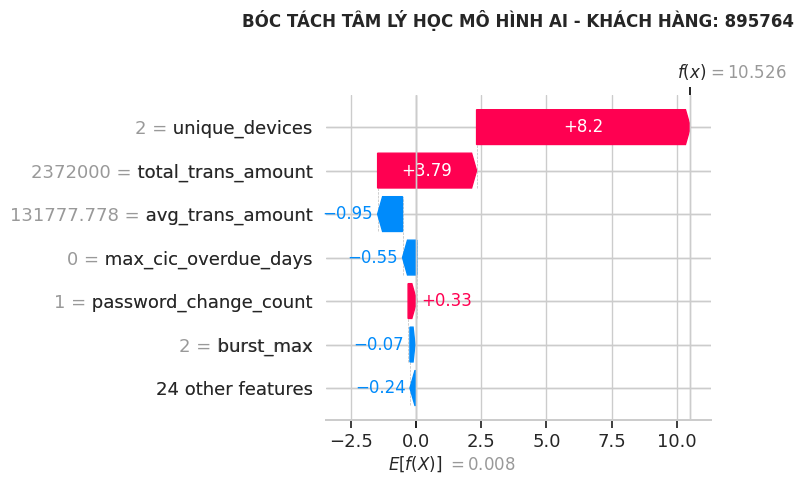

In [ ]:
# Cài đặt thư viện SHAP nếu Colab chưa có sẵn
!pip install shap -q

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

print("\n--- BƯỚC 11 (BẢN TOÀN DIỆN EXCEL): HỆ THỐNG GIẢI THÍCH AI VÀ KẾT XUẤT BIÊN BẢN SHAP ---")

# 1. Đọc lại dữ liệu chuẩn sau Bước 9
CLEANED_DIR = "/content/drive/MyDrive/Gcontest/cleaned"
df_final_report = pd.read_csv(os.path.join(CLEANED_DIR, "Customer_360_Master_Data.csv"), low_memory=False)

# 2. Đồng bộ cấu trúc dữ liệu số chuẩn 100% với model để nạp vào SHAP
expected_features = list(model_xgb.get_booster().feature_names)
X_all = df_final_report.copy()
for col in expected_features:
    if col not in X_all.columns:
        X_all[col] = 0

X_all_input = X_all[expected_features].copy()
for col in X_all_input.select_dtypes(include=['object']).columns.tolist():
    le = LabelEncoder()
    X_all_input[col] = le.fit_transform(X_all_input[col].astype(str).fillna('UNKNOWN'))

# ── 3. CHẠY THUẬT TOÁN SHAP TOÀN CỤC ─────────────────────────────────────────
print("🤖 AI đang phân tích mức độ đóng góp hành vi của từng tài khoản nghi vấn...")
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_all_input)

# ── 🌟 4 (MỚI): BÓC TÁCH TOÀN BỘ ĐỂ XUẤT FILE EXCEL GIẢI TRÌNH AI ──────────────
# Lọc lấy tất cả các ca nguy hiểm (Critical và High) để lập biên bản giải trình
target_risk_accounts = df_final_report[df_final_report['Risk_Segment'].isin(['Critical', 'High'])].copy()

excel_records = []

if not target_risk_accounts.empty:
    print("⚡ Đang lập hồ sơ giải trình số liệu SHAP cho các ca rủi ro cao...")

    for idx in target_risk_accounts.index:
        c_number = df_final_report.loc[idx, 'CUSTOMER_NUMBER']
        risk_seg = df_final_report.loc[idx, 'Risk_Segment']
        act_taken = df_final_report.loc[idx, 'Business_Action']

        # Lấy mảng điểm SHAP của riêng khách hàng này
        customer_shap_flows = shap_values.values[idx]

        # Tìm top 3 đặc trưng thúc đẩy rủi ro lớn nhất (giá trị SHAP dương cao nhất)
        top_3_indices = np.argsort(customer_shap_flows)[-3:][::-1]

        reasons_list = []
        for rank, f_idx in enumerate(top_3_indices, 1):
            f_name = X_all_input.columns[f_idx]
            actual_val = df_final_report.loc[idx, f_name]
            shap_weight = customer_shap_flows[f_idx]

            # Định dạng chữ tiền tệ cho dễ nhìn
            if any(k in f_name for k in ['amount', 'balance', 'volatility']):
                try:
                    val_str = f"{float(actual_val):,.0f} VND"
                except:
                    val_str = str(actual_val)
            else:
                val_str = str(actual_val)

            reasons_list.append(f"[{rank}] Biến '{f_name}'={val_str} (Điểm phạt SHAP: +{shap_weight:.3f})")

        # Gộp 3 lý do toán học lại thành một chuỗi
        ai_evidence_str = " || ".join(reasons_list)

        # Thêm vào danh sách bản ghi
        excel_records.append({
            'Mã Khách Hàng (CIF)': c_number,
            'Phân Cấp Rủi Ro': risk_seg,
            'Biện Pháp Vận Hành': act_taken,
            'Luận Chứng Toán Học AI (Top 3 SHAP Drivers)': ai_evidence_str
        })

    # Tạo DataFrame để xuất Excel
    df_shap_excel = pd.DataFrame(excel_records)
    df_shap_excel.index = np.arange(1, len(df_shap_excel) + 1)
    df_shap_excel.index.name = 'STT'

    # Đường dẫn xuất file
    excel_shap_path = os.path.join(CLEANED_DIR, "Bien_Ban_Giai_Trinh_AI_SHAP.xlsx")
    df_shap_excel.to_excel(excel_shap_path, index=True)

    print("=" * 120)
    print(f"✅ XUẤT FILE EXCEL BIÊN BẢN GIẢI TRÌNH AI THÀNH CÔNG!")
    print(f"  📂 Đường dẫn file lưu trên Drive: {excel_shap_path}")
    print(f"  🎯 Tổng số ca rủi ro đã được bóc tách bằng chứng SHAP: {df_shap_excel.shape[0]:,} tài khoản.")
    print("=" * 120)
else:
    print("⚠️ Không có ca rủi ro cao nào để xuất biên bản Excel.")

# ── 📊 5. PREVIEW ĐỒ THỊ THÁC NƯỚC MẪU CHO CA ĐẦU TIÊN ĐỂ COPIED LÊN SLIDE ──
fraud_idx = df_final_report[df_final_report['Fraud'] == 1].index.tolist()
if fraud_idx:
    sample_idx = fraud_idx[0]
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[sample_idx], max_display=7, show=False)
    plt.title(f"BÓC TÁCH TÂM LÝ HỌC MÔ HÌNH AI - KHÁCH HÀNG: {df_final_report.loc[sample_idx, 'CUSTOMER_NUMBER']}", fontsize=12, pad=25, weight='bold')
    plt.tight_layout()
    plt.show()

## Google Colab is available in VS Code!
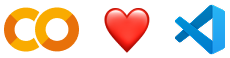

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  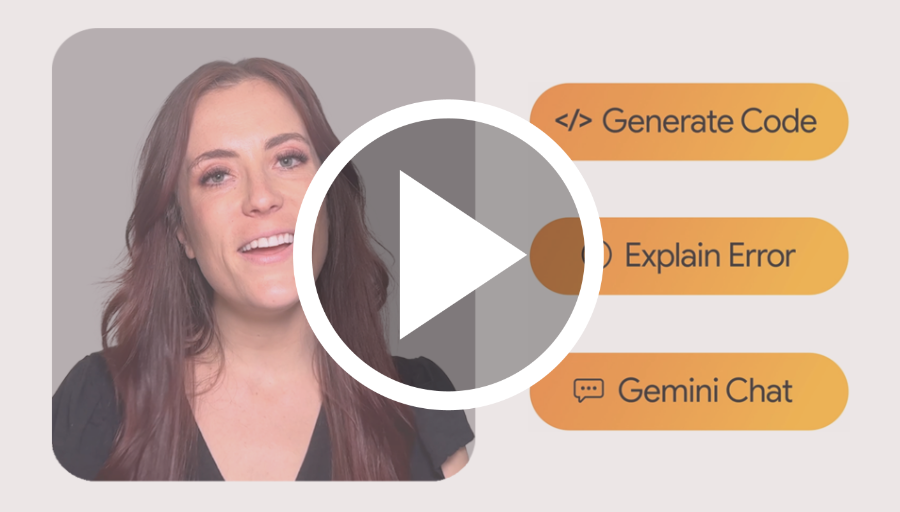
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

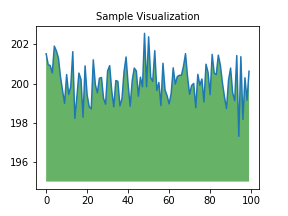

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
